### **DS-3002 Data Mining | Assignment #4 | Spring 2026**
### **Fast-NUCES**
### **Assignment 4 - Heartbeat to Heatmap**
### **Name- Muhammad Noor**
### **RollNo- i232520**
### **Section-A**


In [1]:
import sys
!"{sys.executable}" -m pip install shap

In [2]:
import warnings
warnings.filterwarnings('ignore')

#standard imports
from pathlib import Path
import json
import sys
import time

import matplotlib
if 'ipykernel' not in sys.modules:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

#sklearn imports
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.model_selection import GridSearchCV,StratifiedKFold,train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OneHotEncoder,StandardScaler

#xgboost and shap imports
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE =True
except Exception as exc:
    print('XGBoost unavailable:',exc)
    XGBOOST_AVAILABLE =False

try:
    import shap
    SHAP_AVAILABLE =True
except Exception:
    SHAP_AVAILABLE =False
    print('SHAP is not installed here. Install with: pip install shap')

#tensorflow imports
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from tensorflow.keras.datasets import mnist
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    TF_AVAILABLE =True
except Exception as exc:
    print('TensorFlow unavailable:', exc)
    TF_AVAILABLE =False

try:
    import joblib
    JOBLIB_AVAILABLE=True
except Exception:
    JOBLIB_AVAILABL=False

#plotting settings
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize']=(11, 6)
plt.rcParams['axes.titlesize']=13
plt.rcParams['axes.labelsize']=11

SEED=42
np.random.seed(SEED)
if TF_AVAILABLE:
    tf.random.set_seed(SEED)

#data and directories
DATA_PATH =Path('heart+disease/processed.cleveland.data')
SCREENSHOT_DIR =Path('screenshots')
APP_DIR =Path('app')
SCREENSHOT_DIR.mkdir(exist_ok=True)
APP_DIR.mkdir(exist_ok=True)

#column names and types
COLUMNS =['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
FEATURE_COLS = COLUMNS[:-1]
CATEGORICAL_COLS =['cp', 'restecg', 'slope', 'thal']
CONTINUOUS_COLS =['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
BINARY_COLS=['sex', 'fbs', 'exang']

results={}


#utility functions
def make_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

def save_fig(name):
    path=SCREENSHOT_DIR / f'{name}.jpg'
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches='tight')
    print('Saved:',path)


#evaluation function for binary classification
def eval_binary(name,model,X_test,y_test,proba=None):
    pred =model.predict(X_test)
    if proba is None:
        proba =model.predict_proba(X_test)[:,1] if hasattr(model,'predict_proba') else pred
    p, r, f1, _ =precision_recall_fscore_support(y_test, pred, average='macro', zero_division=0)
    disease_recall =precision_recall_fscore_support(y_test, pred, average=None, zero_division=0)[1][1]
    metrics={
        'accuracy': accuracy_score(y_test, pred),
        'macro_precision': p,
        'macro_recall': r,
        'macro_f1': f1,
        'auc_roc': roc_auc_score(y_test, proba),
        'recall_disease': disease_recall,
    }

    #report and confusion matrix
    print(f'\n{name} classification report:')
    print(classification_report(y_test, pred, target_names=['No Disease','Disease Present'], zero_division=0))
    print({k: round(v,4) for k, v in metrics.items()})
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=['No Disease','Disease Present']).plot(cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    save_fig(name.lower().replace(' ', '_') + '_confusion_matrix')
    plt.show()
    return metrics,pred,proba


## **Part I: Required Preprocessing [12 Marks]**

### **Pre-1 to Pre-5. Loading, cleaning, class balance, one-hot encoding, scaling, and fixed split**

#### **The preprocessing cell keeps the raw UCI category codes, drops only true missing rows, and creates the exact 80/20 stratified split reused later.**


In [3]:
#data loading and preprocessing
raw_df=pd.read_csv(DATA_PATH,names=COLUMNS,na_values='?')
print('Raw shape:', raw_df.shape)
display(raw_df.head())
print('\nData types:')
print(raw_df.dtypes)

missing_counts=raw_df.isna().sum()
print('\nAffected missing-value columns:')
print(missing_counts[missing_counts > 0])
print('Rows with any missing value:', int(raw_df.isna().any(axis=1).sum()))

#dropping rows with missing values and create binary target
heart_df=raw_df.dropna().copy()
heart_df['target_original']=heart_df['target'].astype(int)
heart_df['target'] =(heart_df['target_original'] > 0).astype(int)
for col in CATEGORICAL_COLS +BINARY_COLS +['target']:
    heart_df[col] =heart_df[col].astype(int)

#report on retained data and class balance
print('\nFinal retained rows:',len(heart_df))
print('\nRaw UCI category values retained:')
for col in CATEGORICAL_COLS +BINARY_COLS:
    print(col, sorted(heart_df[col].unique()))

#class distribution
class_dist =heart_df['target'].value_counts().sort_index().rename_axis('target').to_frame('count')
class_dist['percent'] =(class_dist['count'] / len(heart_df) * 100).round(2)
display(class_dist)
print('Decision: no SMOTE/class weighting needed; the binary split is close to balanced.')

X_original =heart_df[FEATURE_COLS].copy()
y =heart_df['target'].copy()
X_train_raw, X_test_raw,y_train,y_test =train_test_split(
    X_original, y,test_size=0.20, stratify=y, random_state=SEED)

preprocessor=ColumnTransformer(
    transformers=[
        ('continuous',StandardScaler(),CONTINUOUS_COLS),
        ('categorical',make_encoder(),CATEGORICAL_COLS),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,)

#fit and transform
X_train =preprocessor.fit_transform(X_train_raw)
X_test =preprocessor.transform(X_test_raw)
feature_names =preprocessor.get_feature_names_out().tolist()
X_train_df =pd.DataFrame(X_train, columns=feature_names, index=X_train_raw.index)
X_test_df =pd.DataFrame(X_test, columns=feature_names, index=X_test_raw.index)
print('Train/test shapes after preprocessing:', X_train_df.shape, X_test_df.shape)
print(feature_names)


Raw shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Affected missing-value columns:
ca      4
thal    2
dtype: int64
Rows with any missing value: 6

Final retained rows: 297

Raw UCI category values retained:
cp [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
restecg [np.int64(0), np.int64(1), np.int64(2)]
slope [np.int64(1), np.int64(2), np.int64(3)]
thal [np.int64(3), np.int64(6), np.int64(7)]
sex [np.int64(0), np.int64(1)]
fbs [np.int64(0), np.int64(1)]
exang [np.int64(0), np.int64(1)]


,count,percent
target,,
0,160,53.87
1,137,46.13


Decision: no SMOTE/class weighting needed; the binary split is close to balanced.
Train/test shapes after preprocessing: (237, 22) (60, 22)
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'cp_1', 'cp_2', 'cp_3', 'cp_4', 'restecg_0', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'slope_3', 'thal_3', 'thal_6', 'thal_7', 'sex', 'fbs', 'exang']


### **Pre-6. Correlation Heatmap**

#### **The heatmap uses the original numeric variables before encoding and checks whether correlations could weaken Naive Bayes independence.**


Saved: screenshots\pre_correlation_heatmap.jpg


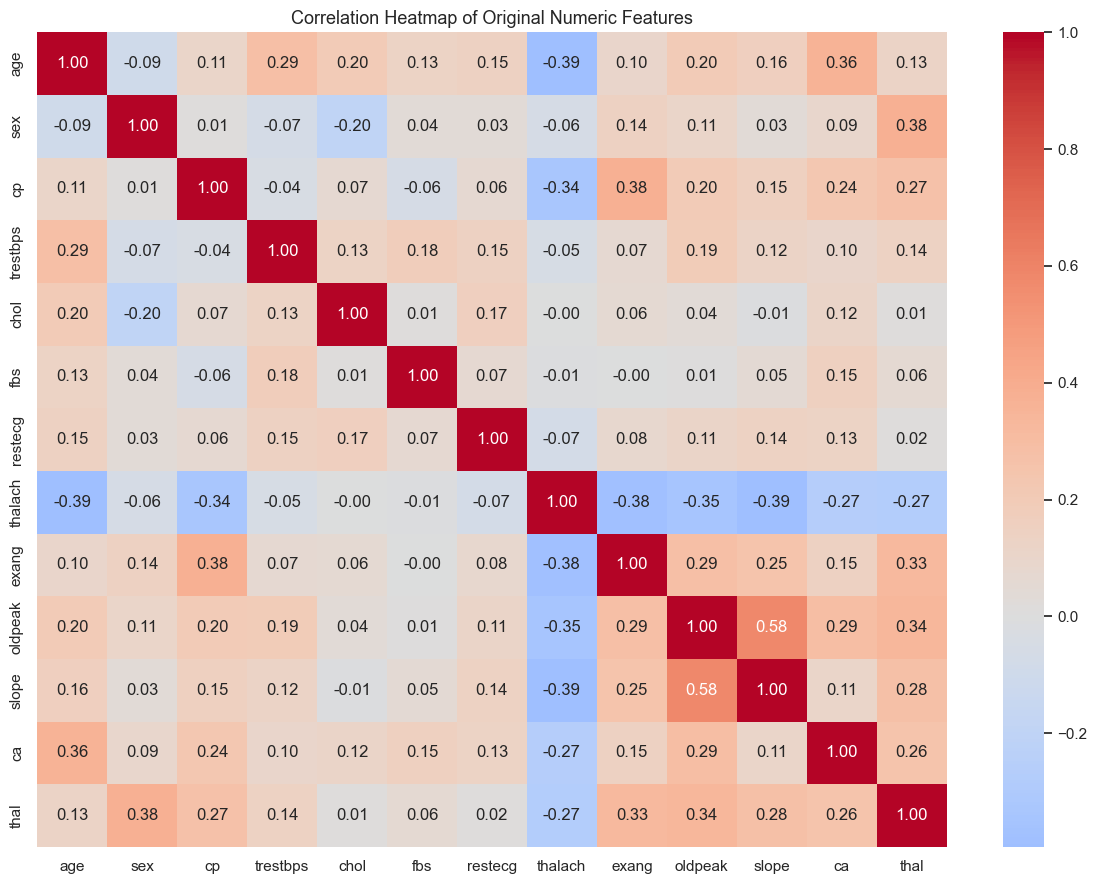

,feature_1,feature_2,abs_corr,signed_corr
0,oldpeak,slope,0.5790,0.5790
1,age,thalach,0.3946,-0.3946
2,thalach,slope,0.3893,-0.3893


Naive Bayes note: correlated variables can double-count overlapping evidence, so NB is used only as a baseline.


In [4]:

#correlation analysis
corr =heart_df[FEATURE_COLS].corr(numeric_only=True)
plt.figure(figsize=(12,9))
sns.heatmap(corr,cmap='coolwarm', center=0,annot=True,fmt='.2f')
plt.title('Correlation Heatmap of Original Numeric Features')
save_fig('pre_correlation_heatmap')
plt.show()

pairs=[]

#finding top 3 most correlated pairs (by absolute value) among original features
for i,a in enumerate(FEATURE_COLS):
    for b in FEATURE_COLS[i+1:]:
        pairs.append((a,b,abs(corr.loc[a,b]),corr.loc[a,b]))
top_corr =pd.DataFrame(sorted(pairs,key=lambda x: x[2],reverse=True)[:3],
                        columns=['feature_1','feature_2','abs_corr','signed_corr'])
display(top_corr.round(4))
print('Naive Bayes note: correlated variables can double-count overlapping evidence, so NB is used only as a baseline.')


#### **Preprocessing Interpretation Notes**
##### **The file has 303 rows and 14 columns. After replacing ? with NaN, ca has 4 missing rows and thal has 2, leaving 297 complete patients after dropping missing rows.**
##### **The binary classes are 160 no-disease and 137 disease-present patients, so stratification is enough and SMOTE is unnecessary.**


## **Part A: Unsupervised Learning [20 Marks]**


### **A1. K-Means Clustering**

#### **This cell tunes k from 2 to 8, plots WCSS and silhouette score, compares PCA cluster views with the true label, and prints clinical cluster profiles.**


  File "c:\Users\Muhammad Noor\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Muhammad Noor\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Muhammad Noor\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Muhammad Noor\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        

,k,wcss,silhouette
0,2,2135.1650,0.1744
1,3,1950.4399,0.1246
2,4,1818.3062,0.1232
3,5,1727.5493,0.1207
4,6,1656.1643,0.1228
5,7,1595.3610,0.1023
6,8,1553.6193,0.0909


Chosen k: 2
Saved: screenshots\a1_kmeans_wcss_silhouette.jpg


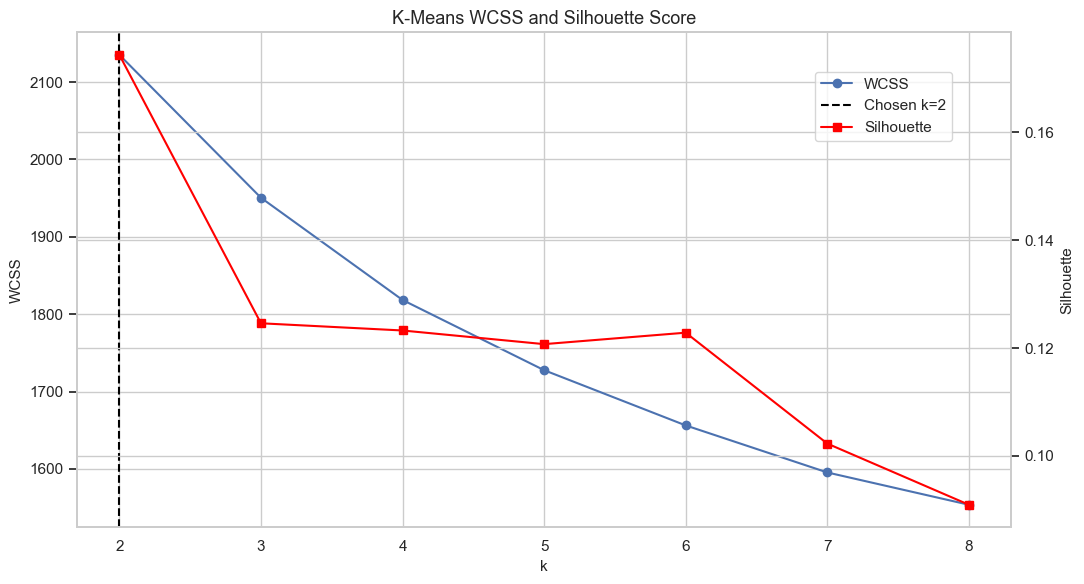

Saved: screenshots\a1_pca_clusters_vs_labels.jpg


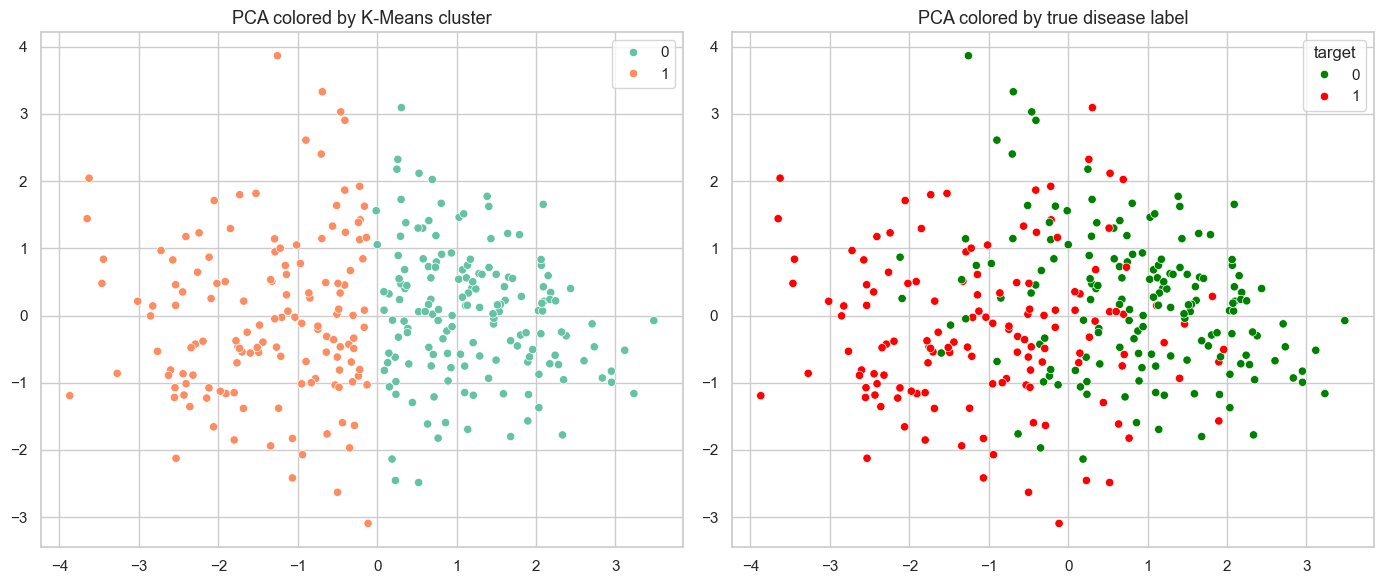

,kmeans_cluster,cluster_size,disease_proportion,mean_thalach,mean_oldpeak,mean_cp
0,0,157,0.204,163.369,0.494,2.885
1,1,140,0.750,134.157,1.685,3.464


ARI between K-Means clusters and true labels: 0.2988


In [5]:
#full preprocessing
full_preprocessor =ColumnTransformer(
    transformers=[('continuous',StandardScaler(),CONTINUOUS_COLS),
                  ('categorical',make_encoder(),CATEGORICAL_COLS)],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

X_full=full_preprocessor.fit_transform(X_original)
full_names=full_preprocessor.get_feature_names_out().tolist()
X_full_df=pd.DataFrame(X_full, columns=full_names, index=heart_df.index)

#K-Means clustering and evaluation
k_rows, models=[],{}
for k in range(2,9):
    km=KMeans(n_clusters=k, random_state=SEED, n_init=25)
    labels=km.fit_predict(X_full_df)
    models[k]=(km, labels)
    k_rows.append({'k': k, 'wcss': km.inertia_,'silhouette': silhouette_score(X_full_df, labels)})
k_scores=pd.DataFrame(k_rows)
chosen_k=int(k_scores.sort_values(['silhouette','k'], ascending=[False,True]).iloc[0]['k'])
kmeans_model, kmeans_labels =models[chosen_k]
heart_df['kmeans_cluster'] =kmeans_labels
display(k_scores.round(4))
print('Chosen k:', chosen_k)

#visualizing K-Means metrics and cluster separation
fig, ax1=plt.subplots(figsize=(11,6))
ax2=ax1.twinx()
ax1.plot(k_scores['k'], k_scores['wcss'], marker='o', label='WCSS')
ax2.plot(k_scores['k'], k_scores['silhouette'], color='red', marker='s', label='Silhouette')
ax1.axvline(chosen_k, color='black', linestyle='--', label=f'Chosen k={chosen_k}')
ax1.set_xlabel('k')
ax1.set_ylabel('WCSS')
ax2.set_ylabel('Silhouette')
plt.title('K-Means WCSS and Silhouette Score')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
save_fig('a1_kmeans_wcss_silhouette')
plt.show()

#visualizing PCA colored by K-Means clusters and true labels
pca2 =PCA(n_components=2,random_state=SEED)
X_pca2 =pca2.fit_transform(X_full_df)
fig, axes =plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=kmeans_labels,palette='Set2',ax=axes[0])
axes[0].set_title('PCA colored by K-Means cluster')
sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], hue=y,palette=['green','red'],ax=axes[1])
axes[1].set_title('PCA colored by true disease label')
save_fig('a1_pca_clusters_vs_labels')
plt.show()

cluster_profile = heart_df.groupby('kmeans_cluster').agg(
    cluster_size=('target','size'),
    disease_proportion=('target','mean'),
    mean_thalach=('thalach','mean'),
    mean_oldpeak=('oldpeak','mean'),
    mean_cp=('cp','mean'),
).reset_index()
display(cluster_profile.round(3))
print('ARI between K-Means clusters and true labels:', round(adjusted_rand_score(y, kmeans_labels), 4))


#### **A1. Interpretation Notes**
##### **The cluster profile gives each subgroup a clinical face using thalach, oldpeak, and cp. A high-risk cluster should show lower maximum heart rate, higher ST depression, and more severe chest-pain coding.**


### **A2. Hierarchical Clustering**

#### **This cell computes Ward linkage, plots the truncated dendrogram, cuts to the chosen K-Means cluster count, and compares both clusterings with ARI.**


Saved: screenshots\a2_hierarchical_dendrogram.jpg


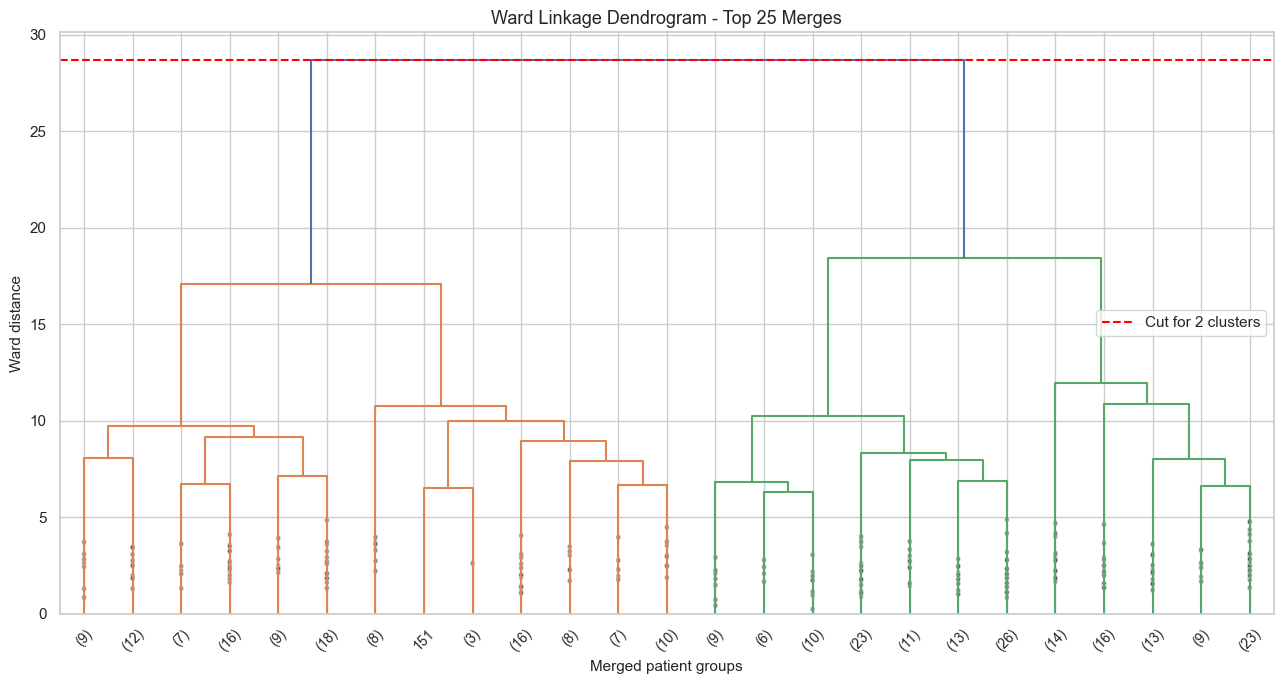

target,No Disease,Disease Present
hier_cluster,,
0,30,94
1,130,43


ARI between K-Means and hierarchical clusters: 0.4562


In [6]:
#hierarchical clustering and evaluation
ward=linkage(X_full_df,method='ward')
plt.figure(figsize=(13,7))
dendrogram(ward, truncate_mode='lastp',p=25, leaf_rotation=45,leaf_font_size=10,show_contracted=True)
plt.title('Ward Linkage Dendrogram - Top 25 Merges')
plt.xlabel('Merged patient groups')
plt.ylabel('Ward distance')
plt.axhline(ward[-chosen_k +1,2],color='red',linestyle='--',label=f'Cut for {chosen_k} clusters')
plt.legend()
save_fig('a2_hierarchical_dendrogram')
plt.show()

#assigning hierarchical cluster labels and compare to K-Means and true labels
hier_labels=fcluster(ward, t=chosen_k, criterion='maxclust') -1
heart_df['hier_cluster'] =hier_labels
ct=pd.crosstab(heart_df['hier_cluster'],heart_df['target']).rename(columns={0: 'No Disease', 1: 'Disease Present'})
display(ct)
print('ARI between K-Means and hierarchical clusters:', round(adjusted_rand_score(kmeans_labels, hier_labels), 4))


#### **A2. Interpretation Notes**
##### **Ward linkage is helpful for seeing nested patient structure, while K-Means is simpler for a clinic workflow. I trust the segmentation more when both methods produce similar assignments and clinically enriched groups.**


### **A3. Dimensionality Reduction**

#### **This cell reports the PCA component count for 90 percent variance and plots t-SNE colored by true disease label.**


Components needed for 90% explained variance: 10
Saved: screenshots\a3_pca_explained_variance.jpg


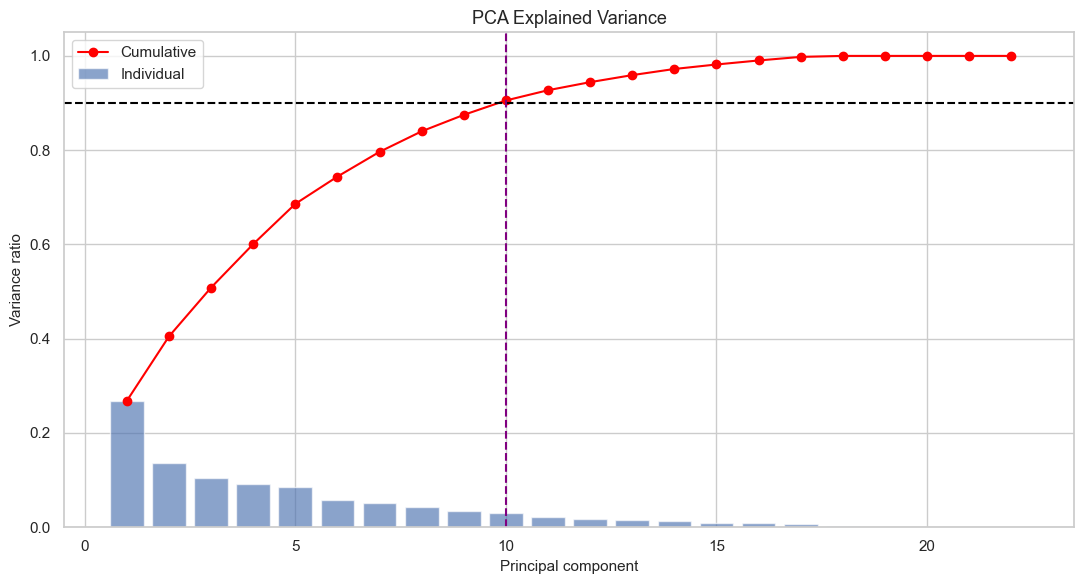

Saved: screenshots\a3_tsne_true_label.jpg


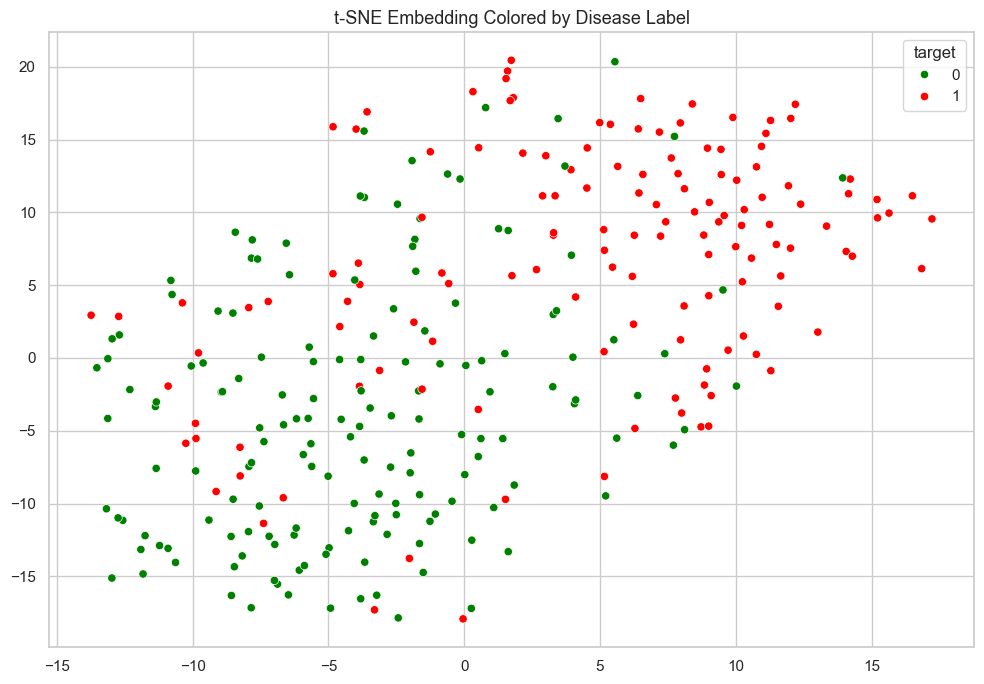

In [7]:

#PCA explained variance analysis and t-SNE visualization
pca=PCA(random_state=SEED).fit(X_full_df)
explained=pca.explained_variance_ratio_
cumulative=np.cumsum(explained)
n90=int(np.argmax(cumulative >=0.90) +1)
print('Components needed for 90% explained variance:',n90)

#visualizing explained variance and cumulative variance
plt.figure(figsize=(11, 6))
plt.bar(np.arange(1,len(explained)+1), explained,alpha=0.65, label='Individual')
plt.plot(np.arange(1,len(cumulative)+1), cumulative, color='red', marker='o', label='Cumulative')
plt.axhline(0.90,color='black', linestyle='--')
plt.axvline(n90,color='purple', linestyle='--')
plt.xlabel('Principal component')
plt.ylabel('Variance ratio')
plt.title('PCA Explained Variance')
plt.legend()
save_fig('a3_pca_explained_variance')
plt.show()

#t-SNE visualization colored by true labels
from sklearn.manifold import TSNE
tsne =TSNE(n_components=2,perplexity=30,random_state=SEED,init='pca',learning_rate='auto')
X_tsne =tsne.fit_transform(X_full_df)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette=['green', 'red'])
plt.title('t-SNE Embedding Colored by Disease Label')
save_fig('a3_tsne_true_label')
plt.show()

#### **A3. Interpretation Notes**
##### **PCA shows how much of the standardized clinical signal is low-dimensional. t-SNE then checks whether the two classes are visibly separable or still overlap in non-linear space.**


## **Part B: Bagging & Boosting [22 Marks]**


### **B1. Random Forest (Bagging)**

#### **This cell tunes n_estimators and max_depth, plots OOB error, plots feature importances, and evaluates the test split.**


Best RF params: {'max_depth': 10, 'n_estimators': 100}
Best CV macro F1: 0.81
Train time: 10.313 seconds
Saved: screenshots\b1_rf_oob_error.jpg


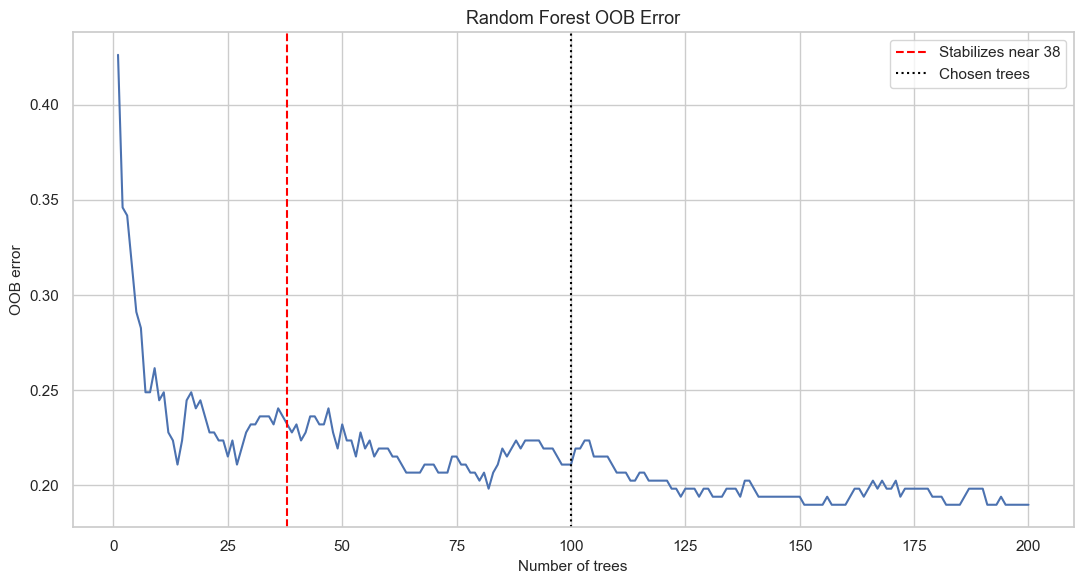

Saved: screenshots\b1_rf_feature_importance.jpg


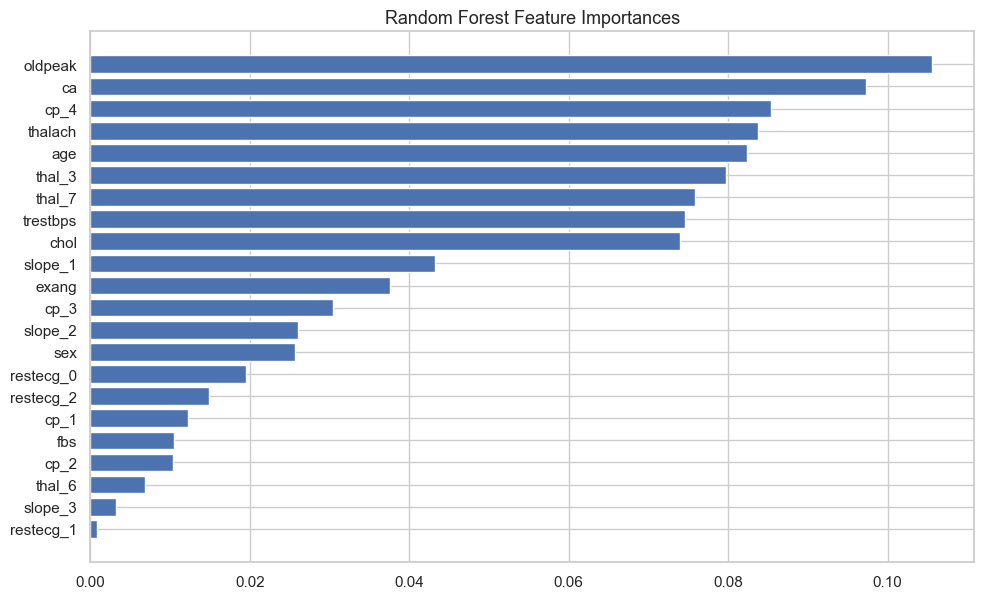

,feature,importance
4,oldpeak,0.1056
5,ca,0.0973
9,cp_4,0.0854
3,thalach,0.0837
0,age,0.0824



Random Forest classification report:
                 precision    recall  f1-score   support

     No Disease       0.80      0.88      0.84        32
Disease Present       0.84      0.75      0.79        28

       accuracy                           0.82        60
      macro avg       0.82      0.81      0.81        60
   weighted avg       0.82      0.82      0.82        60

{'accuracy': 0.8167, 'macro_precision': 0.82, 'macro_recall': 0.8125, 'macro_f1': 0.8141, 'auc_roc': 0.9252, 'recall_disease': np.float64(0.75)}
Saved: screenshots\random_forest_confusion_matrix.jpg


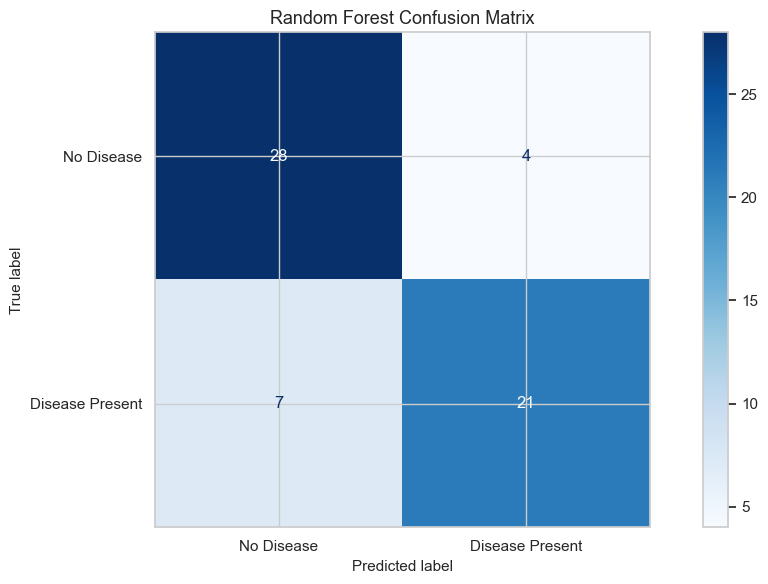

In [8]:

#Random Forest classification with GridSearchCV and OOB analysis
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=SEED, oob_score=True,bootstrap=True, n_jobs=-1),
    {'n_estimators': [50,100,200], 'max_depth': [None,5,10]},
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED),
    n_jobs=-1,
)

#training and timing
start=time.perf_counter()
rf_grid.fit(X_train_df, y_train)
rf_time=time.perf_counter() - start
best_rf=rf_grid.best_estimator_
print('Best RF params:', rf_grid.best_params_)
print('Best CV macro F1:', round(rf_grid.best_score_, 4))
print('Train time:', round(rf_time, 3), 'seconds')

#out-of-bag error analysis to find stabilization point
oob=[]
for n in range(1,201):
    model=RandomForestClassifier(n_estimators=n,random_state=SEED,oob_score=True,bootstrap=True,n_jobs=-1)
    model.fit(X_train_df, y_train)
    oob.append({'n_estimators': n,'oob_error': 1 -model.oob_score_})
oob_df=pd.DataFrame(oob)
stable_candidate=oob_df.loc[oob_df['oob_error'].rolling(10).std().fillna(999).lt(0.005), 'n_estimators'].min()
stable=int(stable_candidate) if pd.notna(stable_candidate) else int(oob_df.loc[oob_df['oob_error'].idxmin(),'n_estimators'])
plt.figure(figsize=(11,6))
plt.plot(oob_df['n_estimators'],oob_df['oob_error'])
plt.axvline(stable, color='red', linestyle='--', label=f'Stabilizes near {stable}')
plt.axvline(rf_grid.best_params_['n_estimators'],color='black', linestyle=':',label='Chosen trees')
plt.xlabel('Number of trees')
plt.ylabel('OOB error')
plt.title('Random Forest OOB Error')
plt.legend()
save_fig('b1_rf_oob_error')
plt.show()


#importance analysis and evaluation on test set
importance=pd.DataFrame({'feature': feature_names,'importance': best_rf.feature_importances_}).sort_values('importance')
plt.figure(figsize=(10,max(6,len(importance) *0.28)))
plt.barh(importance['feature'],importance['importance'])
plt.title('Random Forest Feature Importances')
save_fig('b1_rf_feature_importance')
plt.show()
top5_rf =importance.sort_values('importance',ascending=False).head(5)
display(top5_rf.round(4))
rf_metrics, rf_pred, rf_proba = eval_binary('Random Forest',best_rf,X_test_df,y_test)


#### **B1. Interpretation Notes**
##### **The most clinically plausible RF features are usually thalach, oldpeak, ca, thal, and chest-pain indicators because they describe exercise response, vessel disease, and symptom pattern.**


### **B2. Gradient Boosting with XGBoost**

#### **This cell tunes learning_rate and max_depth, trains with early stopping, plots log-loss, and creates SHAP output when the package is installed.**


Best XGB params: {'learning_rate': 0.3, 'max_depth': 7}
Best CV macro F1: 0.7936
Optimal boosting round: 4
Saved: screenshots\b2_xgb_logloss_curve.jpg


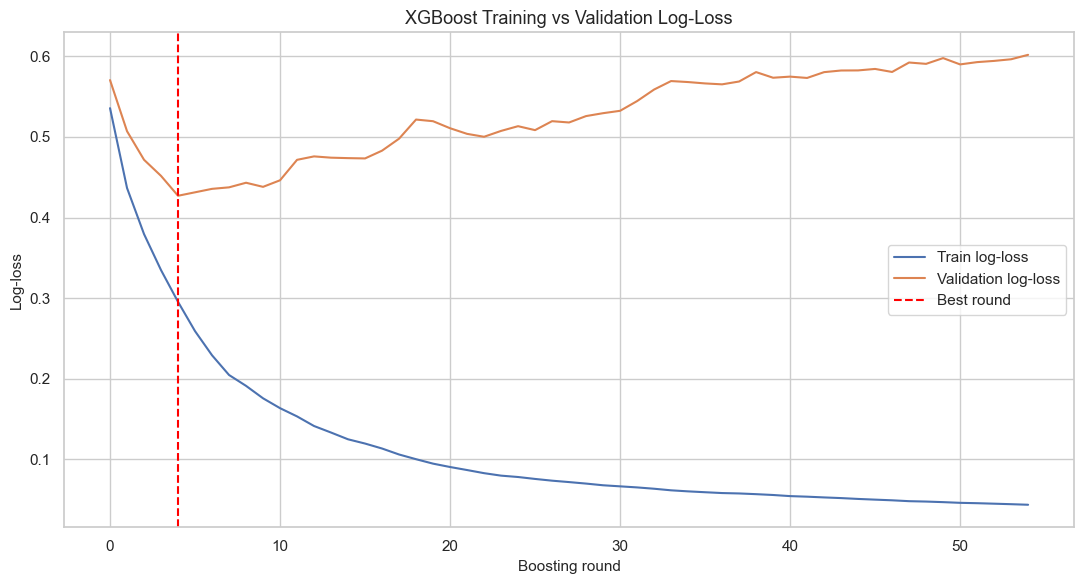

Saved: screenshots\b2_xgb_shap_summary.jpg


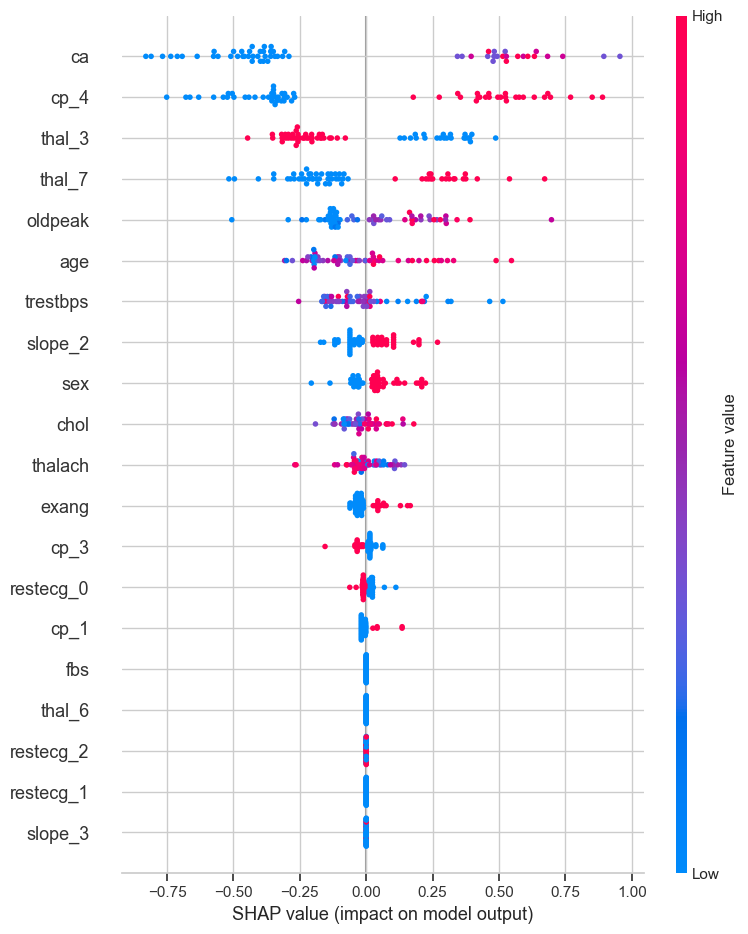


XGBoost classification report:
                 precision    recall  f1-score   support

     No Disease       0.81      0.91      0.85        32
Disease Present       0.88      0.75      0.81        28

       accuracy                           0.83        60
      macro avg       0.84      0.83      0.83        60
   weighted avg       0.84      0.83      0.83        60

{'accuracy': 0.8333, 'macro_precision': 0.8403, 'macro_recall': 0.8281, 'macro_f1': 0.8303, 'auc_roc': 0.9319, 'recall_disease': np.float64(0.75)}
Saved: screenshots\xgboost_confusion_matrix.jpg


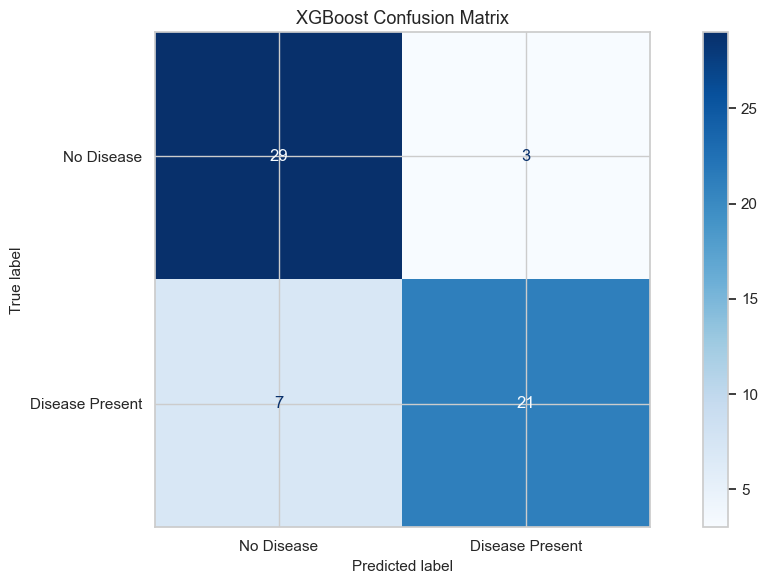

In [9]:

#XGBoost classification with GridSearchCV, early stopping, and SHAP analysis
if XGBOOST_AVAILABLE:
    xgb_grid = GridSearchCV(
        XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=SEED,
                      n_estimators=200,subsample=0.9,colsample_bytree=0.9,n_jobs=-1),
        {'learning_rate': [0.01,0.1,0.3], 'max_depth': [3,5,7]},
        scoring='f1_macro',
        cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED),
        n_jobs=-1,
    )

    #training and timing
    start=time.perf_counter()
    xgb_grid.fit(X_train_df, y_train)
    xgb_cv_time = time.perf_counter()-start
    print('Best XGB params:',xgb_grid.best_params_)
    print('Best CV macro F1:',round(xgb_grid.best_score_, 4))

    X_tr,X_val,y_tr,y_val =train_test_split(X_train_df, y_train, test_size=0.2, stratify=y_train,random_state=SEED)
    best_xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=SEED,
                             n_estimators=500, learning_rate=xgb_grid.best_params_['learning_rate'],
                             max_depth=xgb_grid.best_params_['max_depth'], subsample=0.9,
                             colsample_bytree=0.9, early_stopping_rounds=50, n_jobs=-1)
    
    #refit with early stopping and timing
    start=time.perf_counter()
    best_xgb.fit(X_tr,y_tr, eval_set=[(X_tr,y_tr), (X_val,y_val)],verbose=False)
    xgb_time=time.perf_counter() -start +xgb_cv_time
    print('Optimal boosting round:', best_xgb.best_iteration)

    #visualize log-loss curves and early stopping point
    evals=best_xgb.evals_result()
    plt.figure(figsize=(11,6))
    plt.plot(evals['validation_0']['logloss'], label='Train log-loss')
    plt.plot(evals['validation_1']['logloss'], label='Validation log-loss')
    plt.axvline(best_xgb.best_iteration, color='red', linestyle='--', label='Best round')
    plt.title('XGBoost Training vs Validation Log-Loss')
    plt.xlabel('Boosting round')
    plt.ylabel('Log-loss')
    plt.legend()
    save_fig('b2_xgb_logloss_curve')
    plt.show()

    #SHAP analysis and summary plot
    if SHAP_AVAILABLE:
        explainer=shap.TreeExplainer(best_xgb)
        shap_values=explainer.shap_values(X_test_df)
        shap.summary_plot(shap_values, X_test_df, show=False)
        save_fig('b2_xgb_shap_summary')
        plt.show()
    else:
        print('Install shap before final execution to generate the required SHAP summary plot.')

    xgb_metrics, xgb_pred,xgb_proba =eval_binary('XGBoost',best_xgb,X_test_df,y_test)
else:
    best_xgb=None
    xgb_metrics = None
    xgb_proba = None
    xgb_time=None


#### **B2. Interpretation Notes**
##### **Early stopping is the overfitting guard: if validation log-loss rises while training log-loss falls, the model is beginning to memorize. SHAP explains which clinical features push individual predictions upward or downward.**


### **B3. Ensemble Comparison and ROC**

#### **This cell compares a Gaussian Naive Bayes A3-style baseline, Random Forest, and XGBoost.**



Gaussian Naive Bayes classification report:
                 precision    recall  f1-score   support

     No Disease       0.85      0.88      0.86        32
Disease Present       0.85      0.82      0.84        28

       accuracy                           0.85        60
      macro avg       0.85      0.85      0.85        60
   weighted avg       0.85      0.85      0.85        60

{'accuracy': 0.85, 'macro_precision': 0.8502, 'macro_recall': 0.8482, 'macro_f1': 0.849, 'auc_roc': 0.9141, 'recall_disease': np.float64(0.8214)}
Saved: screenshots\gaussian_naive_bayes_confusion_matrix.jpg


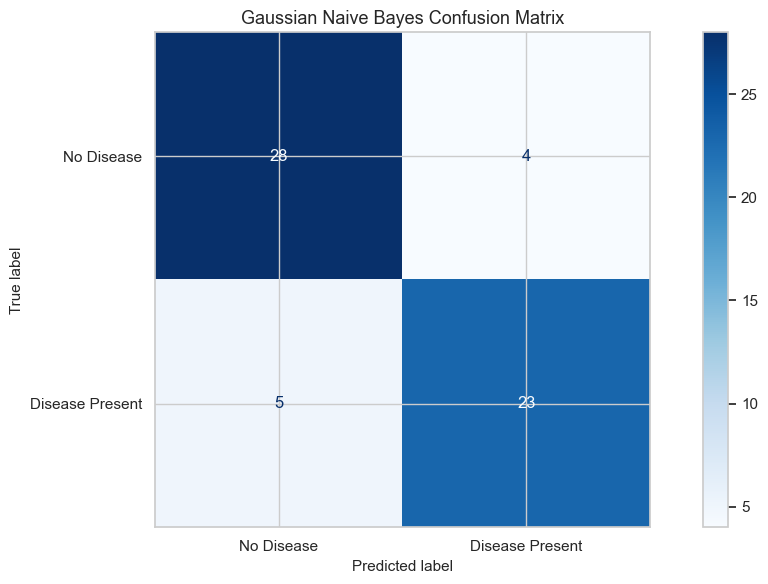

,Classifier,accuracy,macro_precision,macro_recall,macro_f1,auc_roc,recall_disease,train_time
0,Gaussian Naive Bayes,0.8500,0.8502,0.8482,0.8490,0.9141,0.8214,0.0055
1,Random Forest,0.8167,0.8200,0.8125,0.8141,0.9252,0.7500,10.3131
2,XGBoost,0.8333,0.8403,0.8281,0.8303,0.9319,0.7500,0.9055


Saved: screenshots\b3_roc_curves.jpg


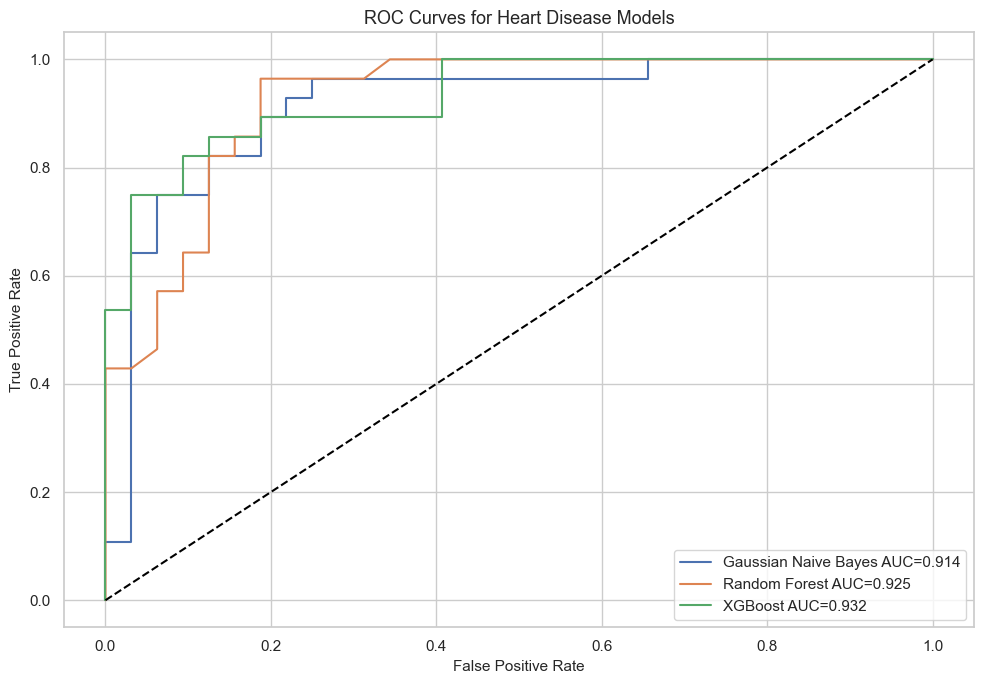

Deployment recommendation: Gaussian Naive Bayes
Recall matters most because false negatives in screening may delay cardiac follow-up.


In [10]:

#gnb baseline and final comparison
gnb=GaussianNB()
start=time.perf_counter()
gnb.fit(X_train_df, y_train)
gnb_time=time.perf_counter() -start
gnb_metrics, gnb_pred, gnb_proba =eval_binary('Gaussian Naive Bayes', gnb,X_test_df,y_test)

#final comparison and deployment recommendation
rows = [
    {'Classifier': 'Gaussian Naive Bayes',**gnb_metrics,'train_time': gnb_time},
    {'Classifier': 'Random Forest',**rf_metrics,'train_time': rf_time},
]
if xgb_metrics is not None:
    rows.append({'Classifier': 'XGBoost',**xgb_metrics,'train_time': xgb_time})
comparison=pd.DataFrame(rows)
display(comparison.round(4))

#visualizing ROC curves for all models
plt.figure(figsize=(10,7))
for name, proba in [('Gaussian Naive Bayes',gnb_proba),('Random Forest', rf_proba)]:
    fpr, tpr, _ =roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} AUC={roc_auc_score(y_test, proba):.3f}')
if xgb_proba is not None:
    fpr, tpr, _ =roc_curve(y_test, xgb_proba)
    plt.plot(fpr, tpr, label=f'XGBoost AUC={roc_auc_score(y_test, xgb_proba):.3f}')
plt.plot([0,1], [0,1],color='black',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Heart Disease Models')
plt.legend()
save_fig('b3_roc_curves')
plt.show()

#deployment recommendation based on recall, AUC, and F1-score prioritizing recall for disease detection
deploy_choice=comparison.sort_values(['recall_disease','auc_roc','macro_f1'], ascending=False).iloc[0]['Classifier']
print('Deployment recommendation:', deploy_choice)
print('Recall matters most because false negatives in screening may delay cardiac follow-up.')


## **Part C: Artificial Neural Networks on Tabular Data [20 Marks]**


### **C1. Single-Layer Perceptron**

#### **This cell trains a one-neuron sigmoid model, plots training curves, inspects weights, and evaluates the test set.**


Saved: screenshots\c1_slp_training_curves.jpg


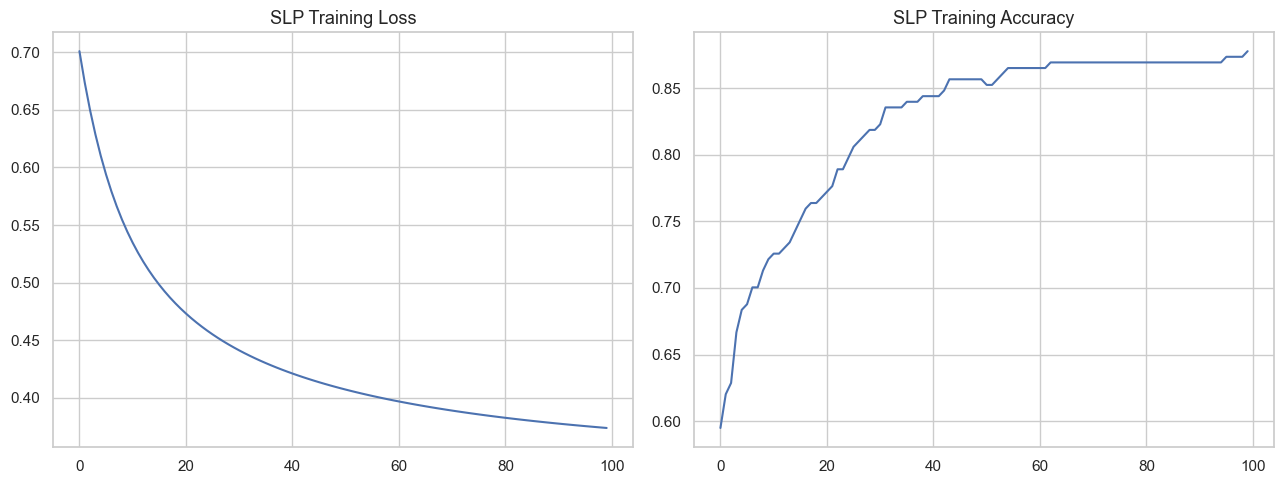

,feature,weight,abs_weight
18,thal_7,0.9304,0.9304
5,ca,0.7835,0.7835
4,oldpeak,0.6399,0.6399


Random Forest top features:


,feature,importance
4,oldpeak,0.1056
5,ca,0.0973
9,cp_4,0.0854
3,thalach,0.0837
0,age,0.0824


Accuracy: 0.8667
F1: 0.8519
AUC: 0.9431
Saved: screenshots\c1_slp_confusion_matrix.jpg


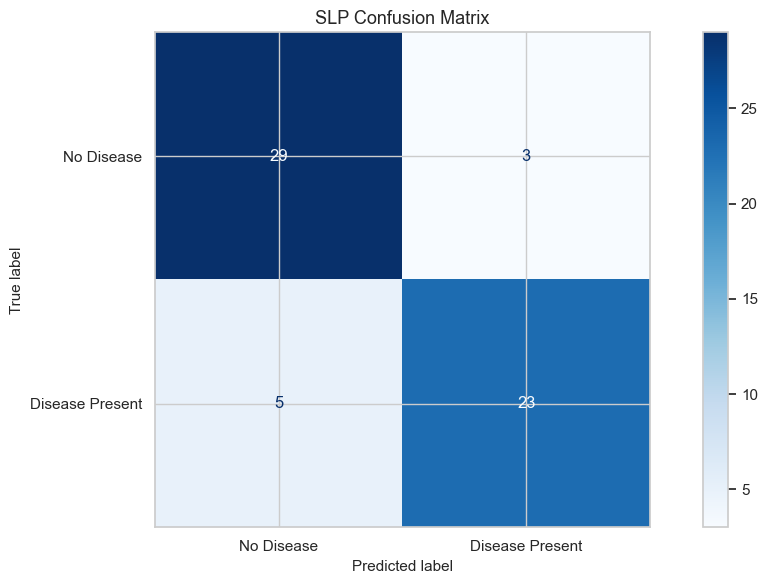

In [11]:

#Single-layer Perceptron (SLP) implementation and evaluation
if TF_AVAILABLE:
    slp=keras.Sequential([layers.Input(shape=(X_train_df.shape[1],)),layers.Dense(1, activation='sigmoid',name='output')])
    slp.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),loss='binary_crossentropy',metrics=['accuracy'])
    slp_hist=slp.fit(X_train_df, y_train, epochs=100,batch_size=16,verbose=0)
    fig, axes=plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(slp_hist.history['loss'])
    axes[0].set_title('SLP Training Loss')
    axes[1].plot(slp_hist.history['accuracy'])
    axes[1].set_title('SLP Training Accuracy')
    save_fig('c1_slp_training_curves')
    plt.show()

    #analyzing SLP weights and comparing to Random Forest feature importance
    weights=slp.get_layer('output').get_weights()[0].flatten()
    slp_weights=pd.DataFrame({'feature': feature_names,'weight': weights,'abs_weight': np.abs(weights)}).sort_values('abs_weight', ascending=False)
    display(slp_weights.head(3).round(4))
    print('Random Forest top features:')
    display(top5_rf.round(4))
    slp_proba=slp.predict(X_test_df,verbose=0).flatten()
    slp_pred =(slp_proba >= 0.5).astype(int)
    print('Accuracy:', round(accuracy_score(y_test,slp_pred),4))
    print('F1:', round(f1_score(y_test, slp_pred),4))
    print('AUC:', round(roc_auc_score(y_test, slp_proba),4))
    ConfusionMatrixDisplay(confusion_matrix(y_test, slp_pred), display_labels=['No Disease','Disease Present']).plot(cmap='Blues')
    plt.title('SLP Confusion Matrix')
    save_fig('c1_slp_confusion_matrix')
    plt.show()


#### **C1. Interpretation Notes**
##### **The SLP is limited because it is linear after preprocessing. It cannot naturally capture interactions between exercise response, chest-pain type, vessel count, and ST depression.**


### **C2. Multi-Layer Perceptron**

#### **This cell compares small, medium, and large MLPs, uses early stopping, runs 5-fold CV, and evaluates the final model.**


,Architecture,Hidden Layers,Val F1,Train Time,Epochs
2,Large,"(128, 64, 32)",0.8333,4.5886,20
0,Small,"(32,)",0.8182,8.3972,36
1,Medium,"(64, 32)",0.8000,8.5758,30


Selected architecture: Large (128, 64, 32)
Saved: screenshots\c2_mlp_final_curves.jpg


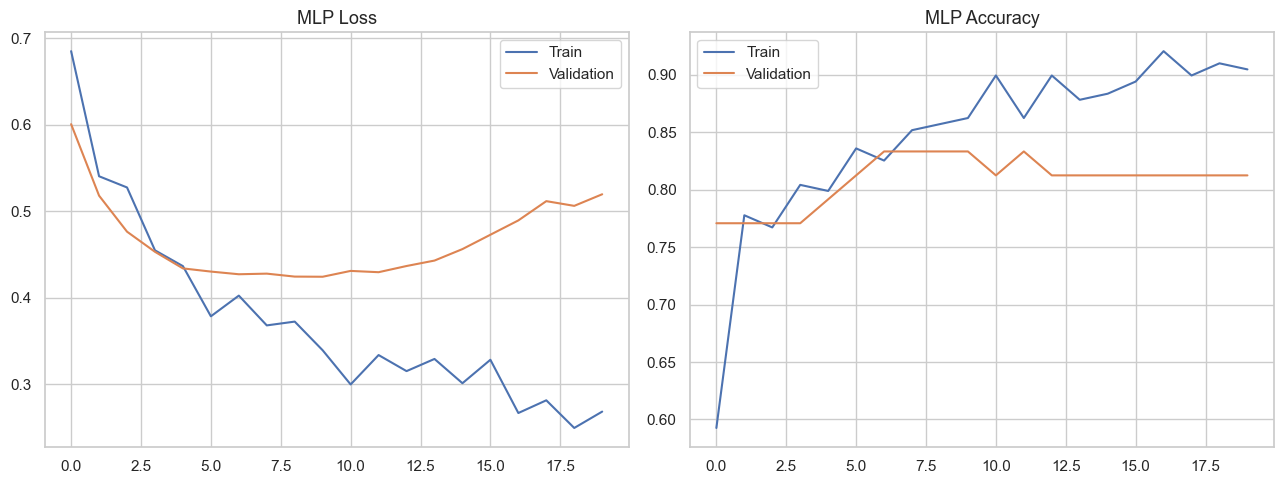

,fold,accuracy,f1
0,1,0.8958,0.8889
1,2,0.8333,0.8000
2,3,0.7021,0.6500
3,4,0.8723,0.8571
4,5,0.7660,0.6857


CV accuracy mean/std: 0.8139 0.0795
CV F1 mean/std: 0.7763 0.1048
Test accuracy: 0.85
Test macro F1: 0.849
Test AUC: 0.9442
Saved: screenshots\c2_mlp_confusion_matrix.jpg


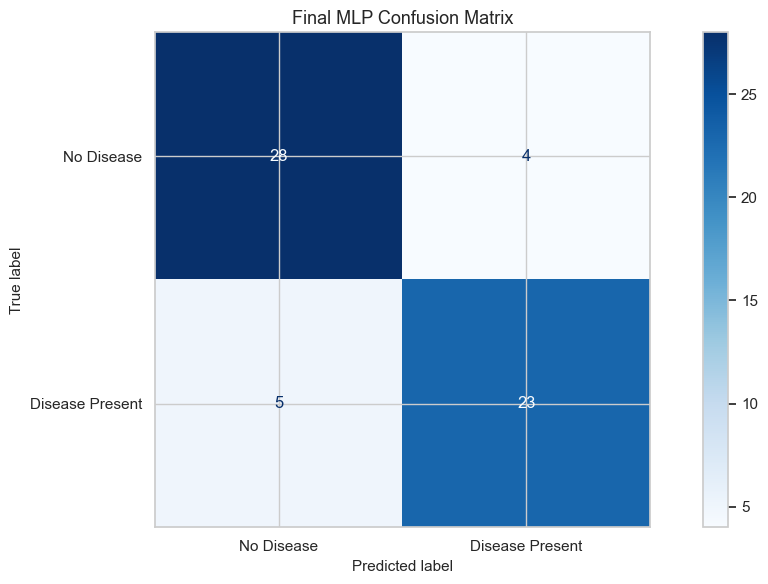

In [12]:

#MLP implementation with configurable architecture, training with early stopping, and evaluation
def build_mlp(input_dim,hidden=(64, 32), activation='relu',dropout=0.25,lr=0.001):
    model =keras.Sequential([layers.Input(shape=(input_dim,))])
    for units in hidden:
        model.add(layers.Dense(units,activation=activation, kernel_regularizer=keras.regularizers.l2(1e-4)))
        if dropout:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

#testing different architectures and selecting the best one based on validation F1-score
if TF_AVAILABLE:
    archs = {'Small': (32,),'Medium': (64, 32), 'Large': (128,64,32)}
    arch_rows, trained=[], {}
    X_tr, X_val, y_tr, y_val = train_test_split(X_train_df, y_train,test_size=0.2,stratify=y_train,random_state=SEED)
    for name, hidden in archs.items():
        model = build_mlp(X_train_df.shape[1], hidden=hidden,dropout=0.25)
        cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        start =time.perf_counter()
        hist=model.fit(X_tr,y_tr,validation_data=(X_val, y_val), epochs=150,batch_size=16,callbacks=[cb],verbose=0)
        elapsed=time.perf_counter() - start
        pred=(model.predict(X_val, verbose=0).flatten() >=0.5).astype(int)
        arch_rows.append({'Architecture': name, 'Hidden Layers': str(hidden), 'Val F1': f1_score(y_val, pred), 'Train Time': elapsed, 'Epochs': len(hist.history['loss'])})
        trained[name] = (model, hist, hidden)
    arch_df = pd.DataFrame(arch_rows).sort_values('Val F1', ascending=False)
    display(arch_df.round(4))
    best_name=arch_df.iloc[0]['Architecture']
    mlp, mlp_hist, best_hidden=trained[best_name]
    print('Selected architecture:', best_name, best_hidden)
    fig, axes=plt.subplots(1, 2,figsize=(13, 5))
    axes[0].plot(mlp_hist.history['loss'], label='Train')
    axes[0].plot(mlp_hist.history['val_loss'], label='Validation')
    axes[0].set_title('MLP Loss')
    axes[0].legend()
    axes[1].plot(mlp_hist.history['accuracy'], label='Train')
    axes[1].plot(mlp_hist.history['val_accuracy'], label='Validation')
    axes[1].set_title('MLP Accuracy')
    axes[1].legend()
    save_fig('c2_mlp_final_curves')
    plt.show()

    #cross-validation evaluation of the final MLP architecture
    cv_rows=[]
    skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)
    for fold, (tr,val) in enumerate(skf.split(X_train_df, y_train),1):
        model=build_mlp(X_train_df.shape[1],hidden=best_hidden,dropout=0.25)
        cb=keras.callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)
        model.fit(X_train_df.iloc[tr], y_train.iloc[tr],validation_data=(X_train_df.iloc[val], y_train.iloc[val]), epochs=150, batch_size=16, callbacks=[cb], verbose=0)
        pred=(model.predict(X_train_df.iloc[val], verbose=0).flatten() >= 0.5).astype(int)
        cv_rows.append({'fold': fold, 'accuracy': accuracy_score(y_train.iloc[val], pred), 'f1': f1_score(y_train.iloc[val], pred)})
    cv_df = pd.DataFrame(cv_rows)
    display(cv_df.round(4))

    #reporting CV results and final test evaluation
    print('CV accuracy mean/std:', round(cv_df.accuracy.mean(),4), round(cv_df.accuracy.std(),4))
    print('CV F1 mean/std:', round(cv_df.f1.mean(), 4), round(cv_df.f1.std(), 4))
    mlp_proba =mlp.predict(X_test_df,verbose=0).flatten()
    mlp_pred =(mlp_proba>=0.5).astype(int)
    print('Test accuracy:', round(accuracy_score(y_test, mlp_pred), 4))
    print('Test macro F1:', round(f1_score(y_test, mlp_pred, average='macro'), 4))
    print('Test AUC:', round(roc_auc_score(y_test, mlp_proba), 4))
    ConfusionMatrixDisplay(confusion_matrix(y_test, mlp_pred), display_labels=['No Disease', 'Disease Present']).plot(cmap='Blues')
    plt.title('Final MLP Confusion Matrix')
    save_fig('c2_mlp_confusion_matrix')
    plt.show()


### **C3. Ablation Study**

#### **This cell removes dropout, replaces ReLU with sigmoid, and removes early stopping one change at a time.**


Saved: screenshots\c3_ablation_val_loss.jpg


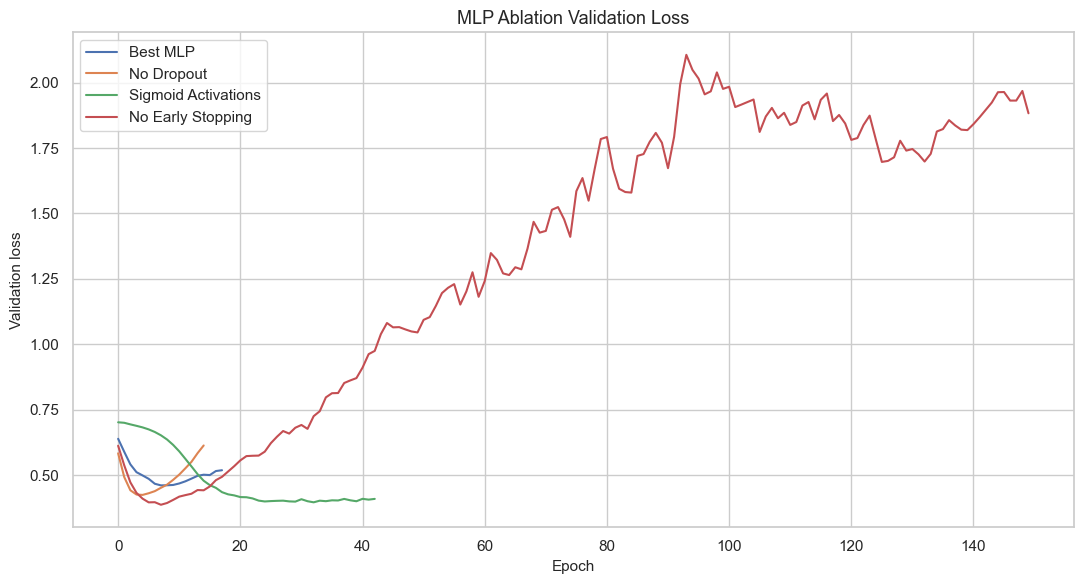

,Variant,Test F1,Epochs
0,Best MLP,0.8302,18
1,No Dropout,0.8302,15
2,Sigmoid Activations,0.8519,43
3,No Early Stopping,0.8571,150


In [13]:

#ablation study on the best MLP architecture to analyze the impact of dropout, activation function, and early stopping
if TF_AVAILABLE and 'mlp' in globals():
    specs={
        'Best MLP': {'dropout': 0.25, 'activation': 'relu', 'early': True, 'epochs': 150},
        'No Dropout': {'dropout': 0.0, 'activation': 'relu', 'early': True, 'epochs': 150},
        'Sigmoid Activations': {'dropout': 0.25, 'activation': 'sigmoid', 'early': True, 'epochs': 150},
        'No Early Stopping': {'dropout': 0.25, 'activation': 'relu', 'early': False, 'epochs': 150},
    }

    #training ablation variants and visualizing validation loss curves
    ab_rows=[]
    plt.figure(figsize=(11,6))
    for name,spec in specs.items():
        model =build_mlp(X_train_df.shape[1], hidden=best_hidden, activation=spec['activation'], dropout=spec['dropout'])
        callbacks =[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)] if spec['early'] else []
        hist =model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=spec['epochs'], batch_size=16, callbacks=callbacks, verbose=0)
        pred=(model.predict(X_test_df, verbose=0).flatten() >= 0.5).astype(int)
        ab_rows.append({'Variant': name, 'Test F1': f1_score(y_test, pred), 'Epochs': len(hist.history['loss'])})
        plt.plot(hist.history['val_loss'], label=name)

    #visualizing ablation validation loss curves and report test F1-scores for each variant
    plt.title('MLP Ablation Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Validation loss')
    plt.legend()
    save_fig('c3_ablation_val_loss')
    plt.show()
    display(pd.DataFrame(ab_rows).round(4))


## **Part D: CNN on MNIST Digit Images [16 Marks]**


### **D1. Data Preparation and Baseline**

#### **This cell loads the required MNIST subset, displays one digit per class, and trains the dense baseline.**


Saved: screenshots\d1_mnist_samples.jpg


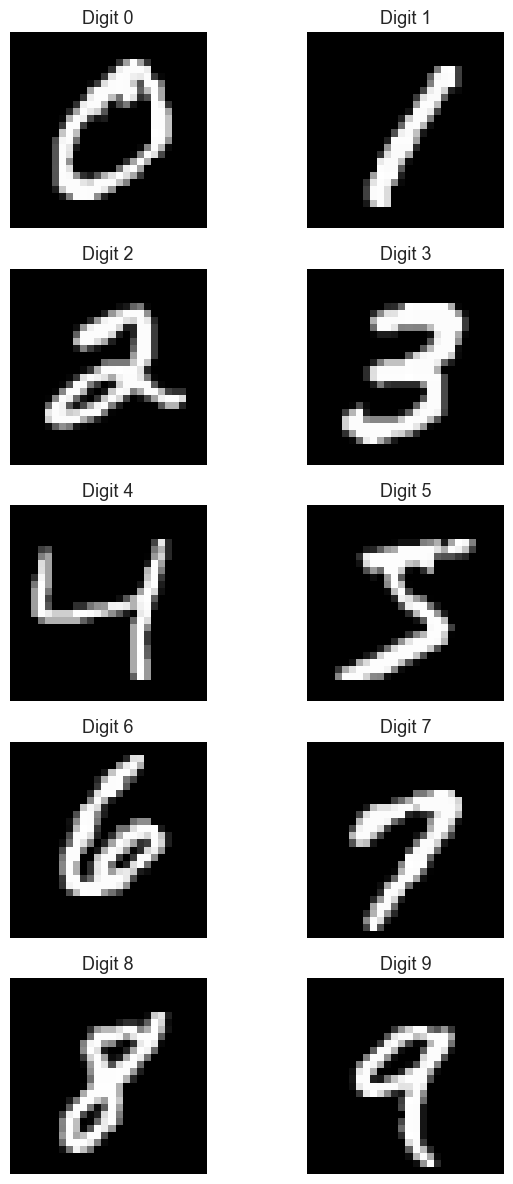

Epoch 1/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8206 - loss: 0.7033 - val_accuracy: 0.9000 - val_loss: 0.3545
Epoch 2/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9225 - loss: 0.2926 - val_accuracy: 0.9208 - val_loss: 0.2789
Epoch 3/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9364 - loss: 0.2319 - val_accuracy: 0.9267 - val_loss: 0.2467
Epoch 4/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9451 - loss: 0.1951 - val_accuracy: 0.9308 - val_loss: 0.2266
Epoch 5/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9532 - loss: 0.1671 - val_accuracy: 0.9333 - val_loss: 0.2121
MLP baseline test accuracy: 0.9095


In [14]:

#MNIST digit classification with MLP baseline and CNN preprocessing
if TF_AVAILABLE:
    #loading
    try:
        (x_train_m,y_train_m),(x_test_m, y_test_m)=mnist.load_data()

        #converting
        x_train_m, y_train_m = x_train_m[:12000].astype('float32') /255.0,y_train_m[:12000]
        x_test_m, y_test_m =x_test_m[:2000].astype('float32') / 255.0,y_test_m[:2000]

        #reshaping
        x_train_cnn, x_test_cnn=x_train_m[..., None], x_test_m[..., None]
        MNIST_READY =True
    except Exception as exc:
        MNIST_READY =False
        print('MNIST could not be loaded in this environment:',exc)

    #reporting data shapes and class distribution
    if MNIST_READY:
        #plotting
        fig, axes =plt.subplots(5, 2, figsize=(7, 12))
        for digit, ax in enumerate(axes.ravel()):
            idx =np.where(y_train_m ==digit)[0][0]
            ax.imshow(x_train_m[idx], cmap='gray')
            ax.set_title(f'Digit {digit}')
            ax.axis('off')
        save_fig('d1_mnist_samples')
        plt.show()

        #building
        mnist_mlp =keras.Sequential([layers.Input(shape=(28, 28, 1)),layers.Flatten(),layers.Dense(64,activation='relu'), layers.Dense(10,activation='softmax')])
        mnist_mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        #training
        mnist_mlp.fit(x_train_cnn,y_train_m,epochs=5,batch_size=64,validation_split=0.1,verbose=1)

        #evaluating
        _, baseline_acc = mnist_mlp.evaluate(x_test_cnn, y_test_m, verbose=0)
        print('MLP baseline test accuracy:', round(baseline_acc, 4))


### **D2. Lightweight CNN**

#### **This cell trains the required two-block CNN, reports accuracy and macro F1, and identifies the most confused digit pairs.**


Epoch 1/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.6329 - loss: 1.1131 - val_accuracy: 0.8775 - val_loss: 0.4263
Epoch 2/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8631 - loss: 0.4471 - val_accuracy: 0.9125 - val_loss: 0.3034
Epoch 3/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8989 - loss: 0.3313 - val_accuracy: 0.9350 - val_loss: 0.2213
Epoch 4/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9189 - loss: 0.2666 - val_accuracy: 0.9483 - val_loss: 0.1748
Epoch 5/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9255 - loss: 0.2446 - val_accuracy: 0.9475 - val_loss: 0.1712
Epoch 6/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9338 - loss: 0.2149 - val_accuracy: 0.9558 - val_loss: 0.1534
Epoch 7/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9371 - loss: 0.2027 - val_accuracy: 0.9608 - val_loss: 0.1261
Epoch 8/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9414 - loss: 0.1831 - val_accu

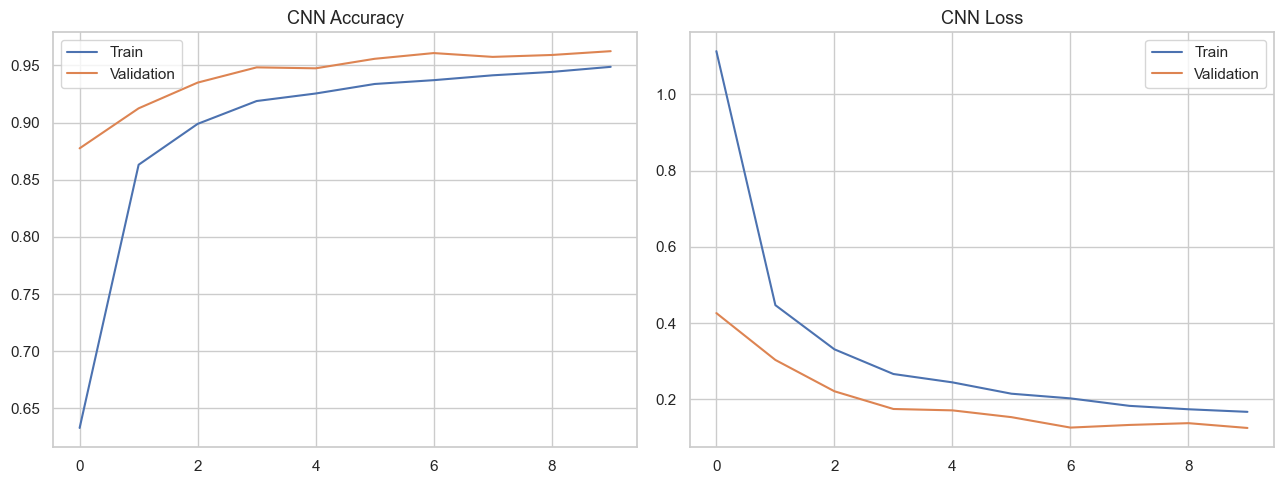

CNN test accuracy: 0.981
CNN macro F1: 0.9807
Saved: screenshots\d2_cnn_confusion_matrix.jpg


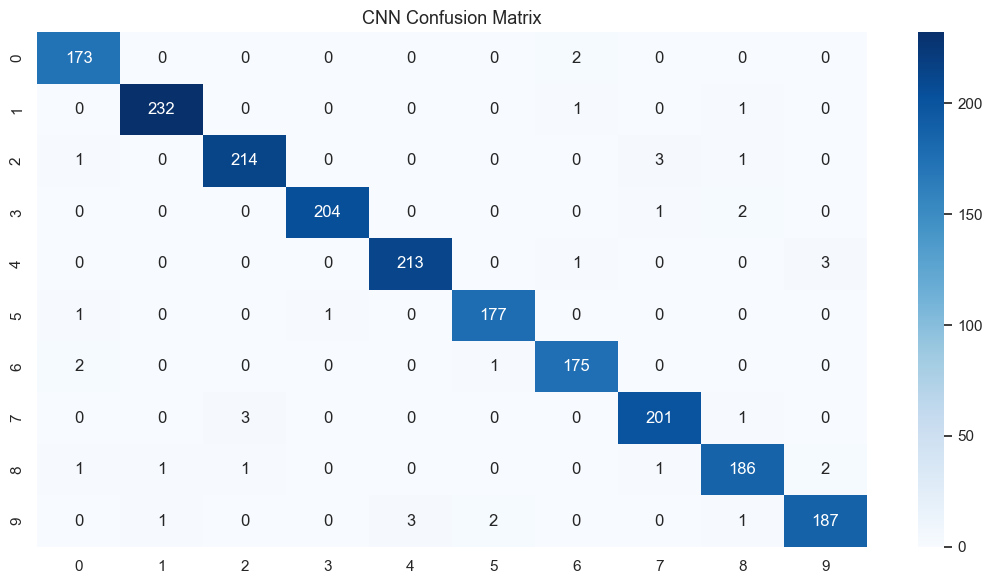

Most confused digit pairs: [(2, 7, 3), (4, 9, 3)]


In [15]:
#CNN implementation for MNIST digit classification
if TF_AVAILABLE and globals().get('MNIST_READY', False):
    #building
    cnn = keras.Sequential([
        layers.Input(shape=(28,28,1)),
        layers.Conv2D(16, (3,3), activation='relu', padding='same', name='conv1'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax'),
    ])

    #compiling
    cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

    #augmenting
    datagen=ImageDataGenerator(rotation_range=10,width_shift_range=0.1,height_shift_range=0.1,validation_split=0.1)

    #training
    hist=cnn.fit(datagen.flow(x_train_cnn, y_train_m, batch_size=64,subset='training',seed=SEED),
                   validation_data=datagen.flow(x_train_cnn, y_train_m, batch_size=64, subset='validation',seed=SEED),
                   epochs=10, verbose=1)

    #plotting
    fig, axes =plt.subplots(1,2,figsize=(13, 5))
    axes[0].plot(hist.history['accuracy'], label='Train')
    axes[0].plot(hist.history['val_accuracy'], label='Validation')
    axes[0].set_title('CNN Accuracy')
    axes[0].legend()
    axes[1].plot(hist.history['loss'], label='Train')
    axes[1].plot(hist.history['val_loss'], label='Validation')
    axes[1].set_title('CNN Loss')
    axes[1].legend()
    save_fig('d2_cnn_training_curves')
    plt.show()

    #predicting
    pred = np.argmax(cnn.predict(x_test_cnn, verbose=0), axis=1)
    print('CNN test accuracy:',round(accuracy_score(y_test_m,pred), 4))
    print('CNN macro F1:',round(f1_score(y_test_m, pred, average='macro'), 4))

    #evaluating
    cm=confusion_matrix(y_test_m,pred,labels=list(range(10)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('CNN Confusion Matrix')
    save_fig('d2_cnn_confusion_matrix')
    plt.show()

    #extracting
    cm2 =cm.copy()
    np.fill_diagonal(cm2,0)
    pairs=[]
    for _ in range(2):
        i, j=np.unravel_index(np.argmax(cm2), cm2.shape)
        pairs.append((int(i), int(j), int(cm2[i, j])))
        cm2[i,j]=0
    print('Most confused digit pairs:', pairs)


### **D3. Visualising What the CNN Learned**

#### **This cell displays the 16 learned first-layer filters and feature maps for one image from each digit class.**


Saved: screenshots\d3_cnn_first_layer_filters.jpg


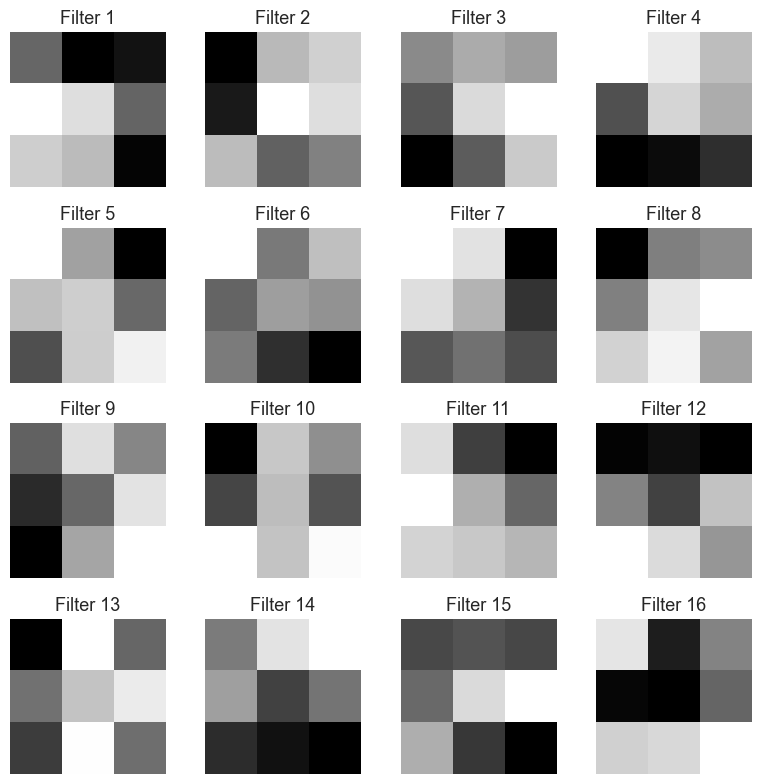

Saved: screenshots\d3_feature_maps_digit_0.jpg


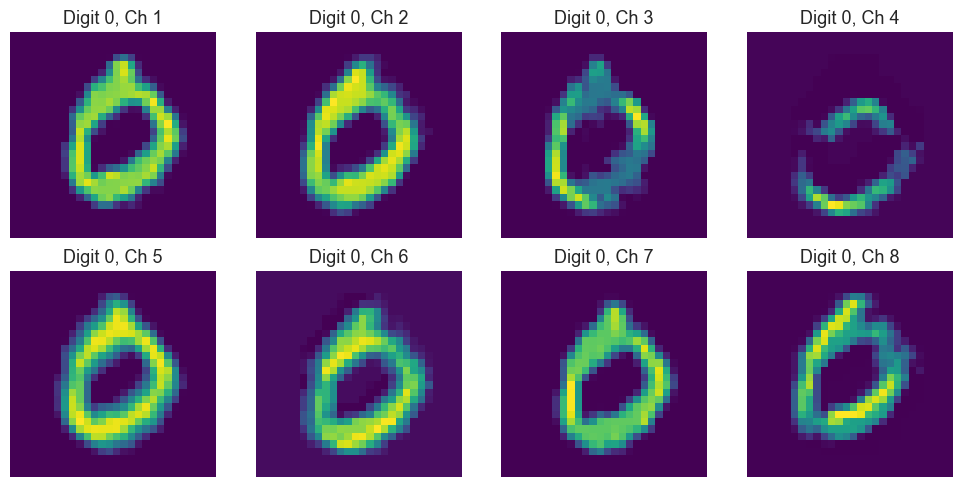

Saved: screenshots\d3_feature_maps_digit_1.jpg


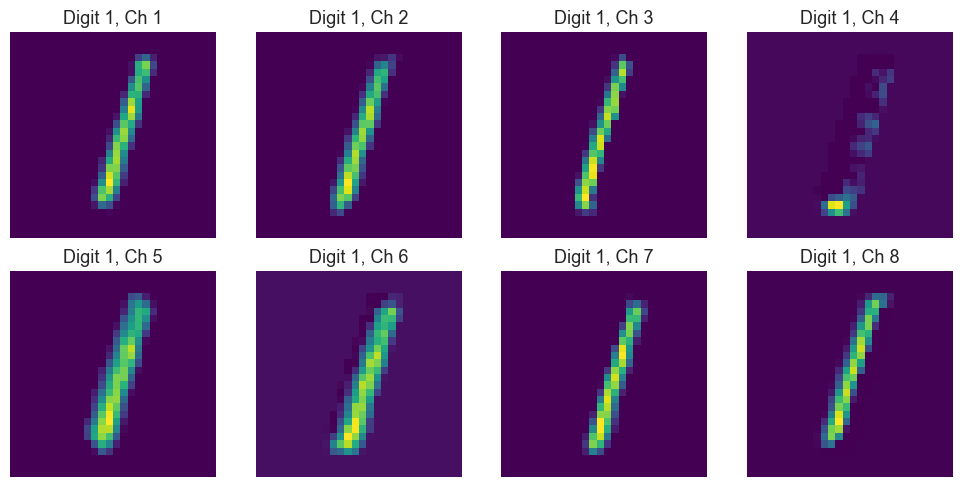

Saved: screenshots\d3_feature_maps_digit_2.jpg


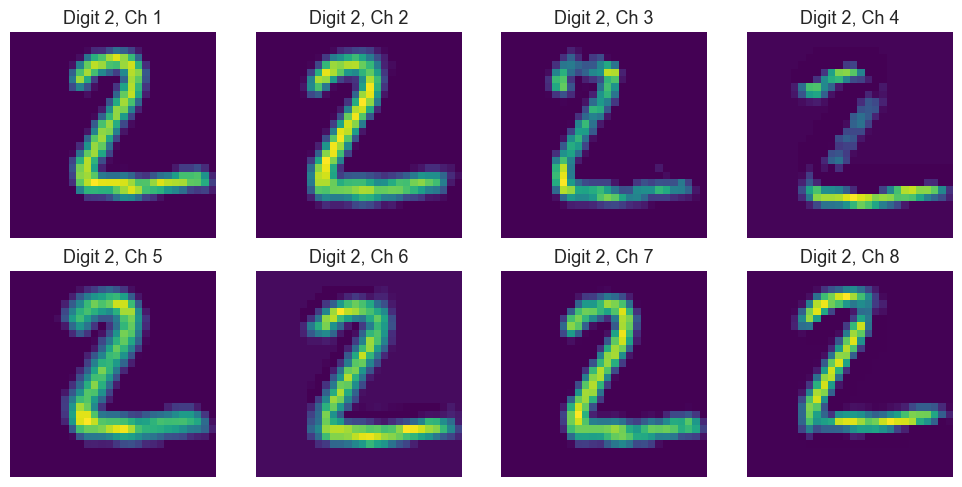

Saved: screenshots\d3_feature_maps_digit_3.jpg


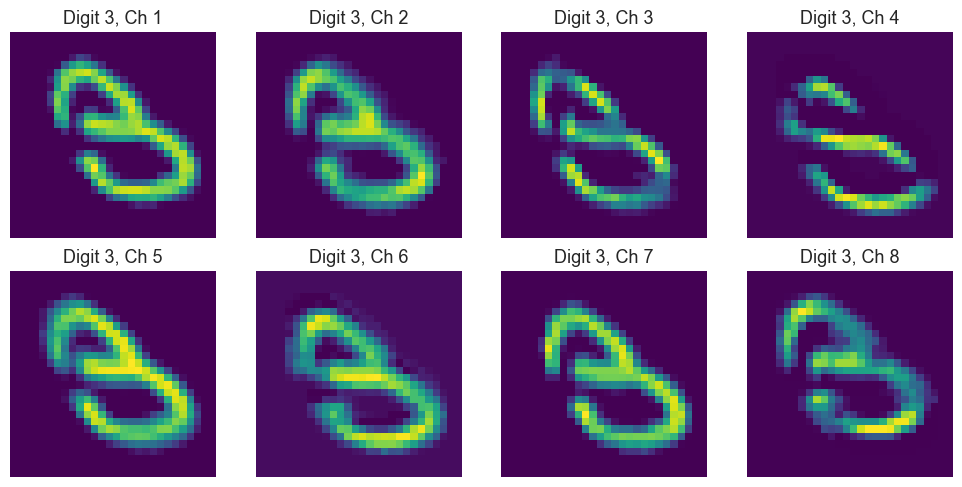

Saved: screenshots\d3_feature_maps_digit_4.jpg


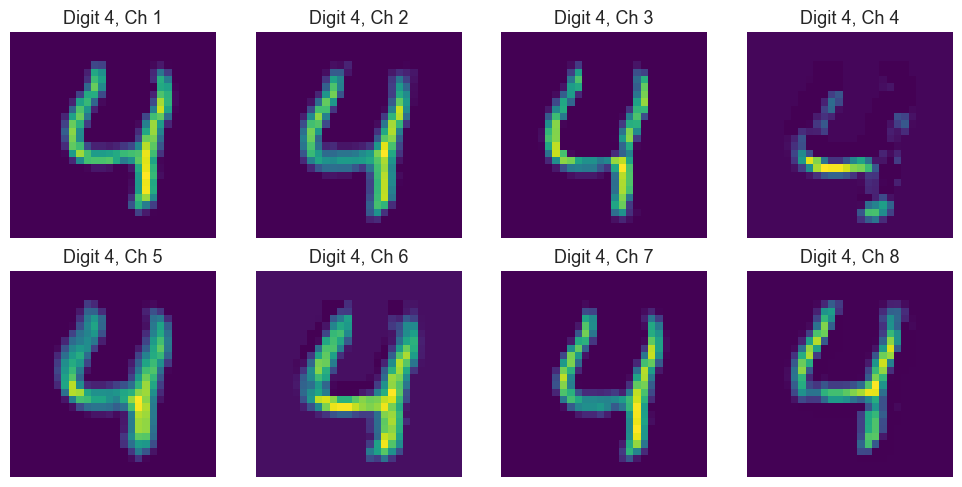

Saved: screenshots\d3_feature_maps_digit_5.jpg


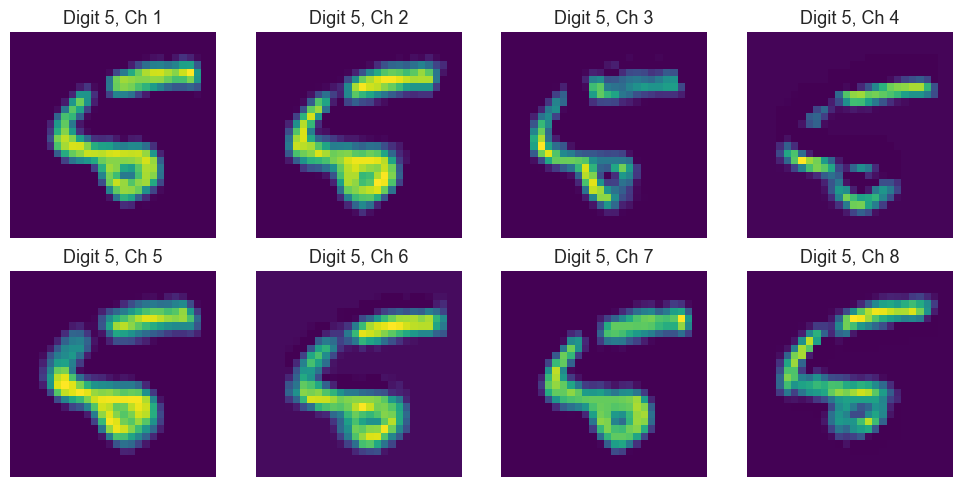

Saved: screenshots\d3_feature_maps_digit_6.jpg


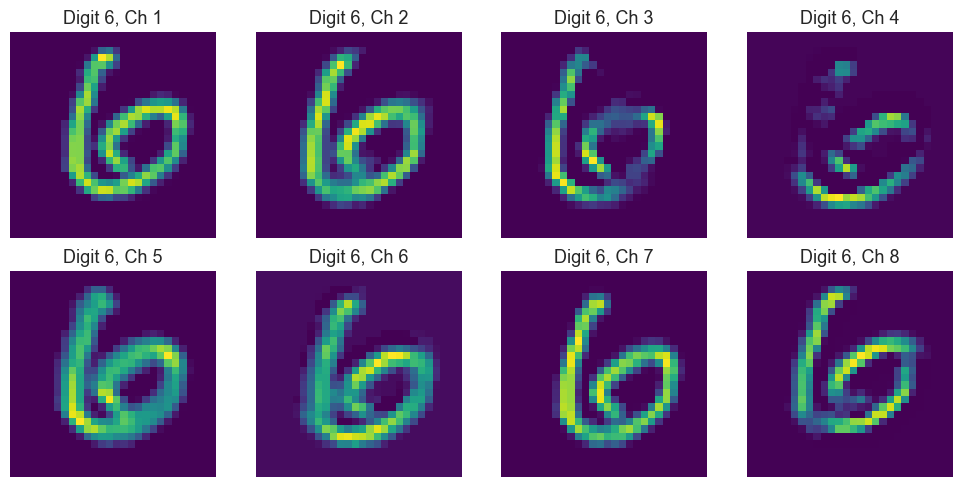

Saved: screenshots\d3_feature_maps_digit_7.jpg


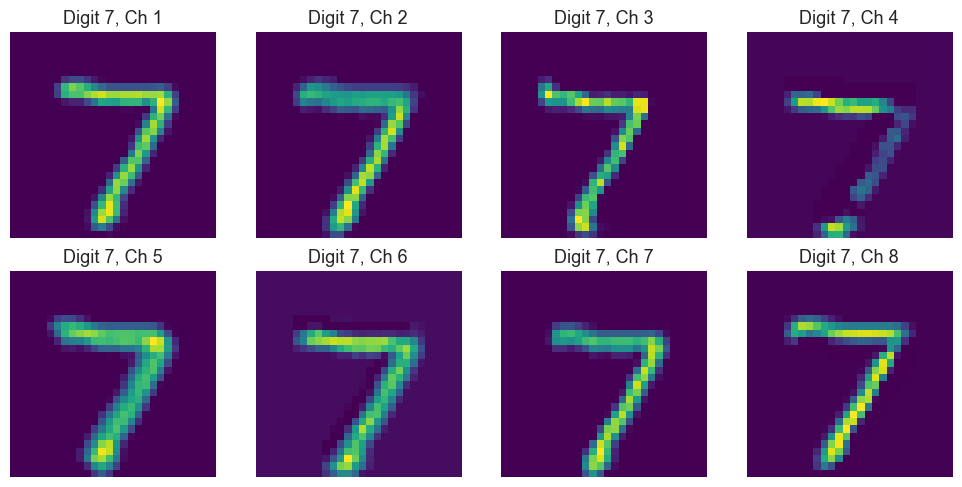

Saved: screenshots\d3_feature_maps_digit_8.jpg


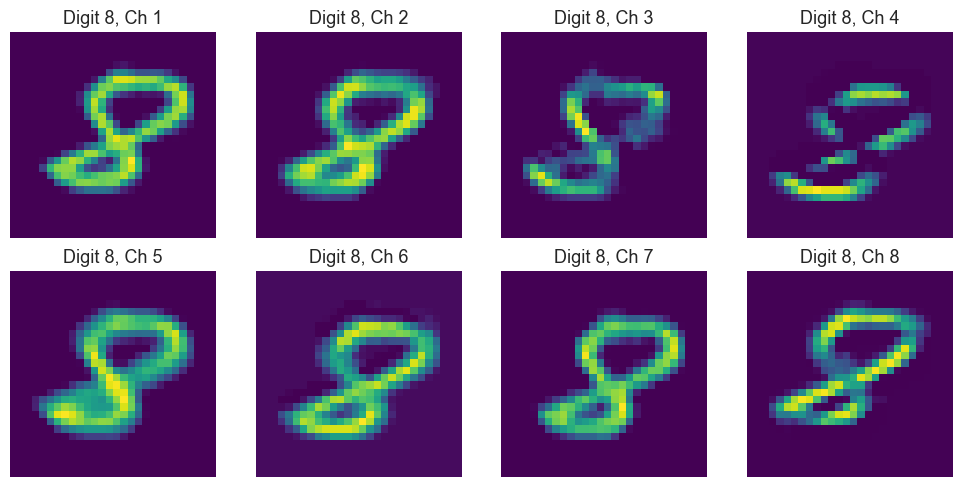

Saved: screenshots\d3_feature_maps_digit_9.jpg


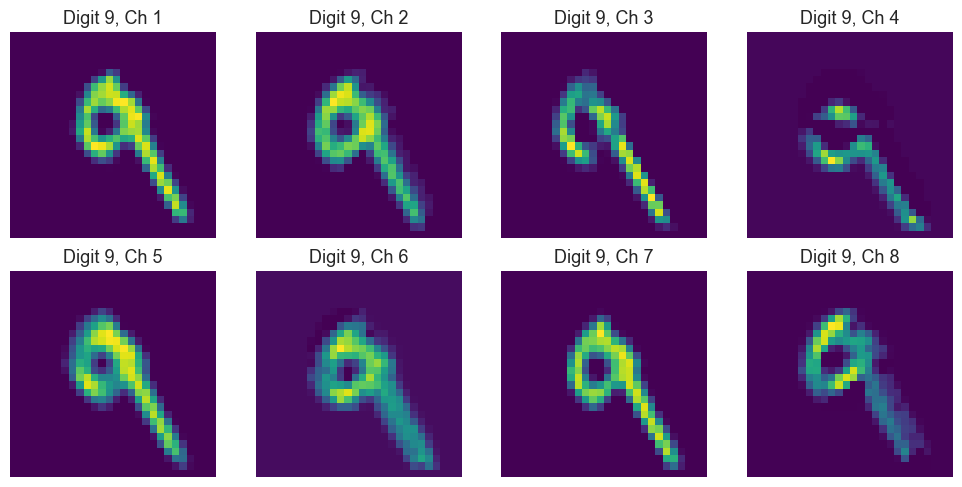

In [16]:

#visualizing CNN filters and feature maps for the first convolutional layer
if TF_AVAILABLE and 'cnn' in globals():
    #getting
    filters=cnn.get_layer('conv1').get_weights()[0]

    #plotting
    fig, axes=plt.subplots(4,4,figsize=(8, 8))
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(filters[:, :, 0,i], cmap='gray')
        ax.set_title(f'Filter {i+1}')
        ax.axis('off')
    save_fig('d3_cnn_first_layer_filters')
    plt.show()

    #building
    input_tensor=keras.Input(shape=x_test_cnn.shape[1:])
    feature_model=keras.Model(
        inputs=input_tensor,
        outputs=cnn.get_layer('conv1')(input_tensor))

    #iterating
    for digit in range(10):
        idx =np.where(y_test_m == digit)[0][0]
        maps=feature_model.predict(x_test_cnn[idx:idx +1],verbose=0)[0]

        #plotting
        fig, axes =plt.subplots(2,4,figsize=(10,5))
        for ch, ax in enumerate(axes.ravel()):
            ax.imshow(maps[:, :,ch],cmap='viridis')
            ax.set_title(f'Digit {digit}, Ch {ch + 1}')
            ax.axis('off')
        save_fig(f'd3_feature_maps_digit_{digit}')
        plt.show()


## **Part E: Local Front-End Dashboard [10 Marks]**


### **E1 to E3. Streamlit dashboard artifacts**

#### **This cell saves the selected model, preprocessing pipeline, requirements.txt, and app.py.**


In [17]:
#selecting
if deploy_choice=='XGBoost' and best_xgb is not None:
    app_model =best_xgb
else:
    app_model=best_rf

#saving
if JOBLIB_AVAILABLE:
    joblib.dump(app_model,APP_DIR / 'model.pkl')
    joblib.dump(preprocessor,APP_DIR / 'preprocessor.pkl')
    with open(APP_DIR /'sample_patient.json', 'w') as f:
        json.dump({k: float(v) for k, v in X_test_raw.iloc[0].to_dict().items()}, f, indent=2)

#writing
(APP_DIR / 'requirements.txt').write_text('''pandas
numpy
scikit-learn
xgboost
shap
tensorflow
streamlit
matplotlib
seaborn
scipy
joblib
''')

#building
app_code = '''
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import streamlit as st

APP_DIR = Path(__file__).resolve().parent
FEATURES = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal']
HINTS = {
    'age':'Age: 20-80', 'sex':'1 male, 0 female', 'cp':'Chest pain type: UCI 1-4',
    'trestbps':'Resting BP: 90-200', 'chol':'Cholesterol: 120-570', 'fbs':'FBS >120: 1/0',
    'restecg':'Resting ECG: 0-2', 'thalach':'Max heart rate: 70-210', 'exang':'Exercise angina: 1/0',
    'oldpeak':'ST depression: 0-7', 'slope':'ST slope: 1-3', 'ca':'Major vessels: 0-3', 'thal':'Thal: 3/6/7'
}
model = joblib.load(APP_DIR / 'model.pkl')
preprocessor = joblib.load(APP_DIR / 'preprocessor.pkl')
sample = json.loads((APP_DIR / 'sample_patient.json').read_text())
st.set_page_config(page_title='CardioAI Heart Disease Dashboard', layout='wide')
st.title('CardioAI Heart Disease Screening')
values = {}
cols = st.columns(2)
for i, feature in enumerate(FEATURES):
    with cols[i % 2]:
        values[feature] = st.number_input(feature, value=float(sample[feature]), help=HINTS[feature], format='%.3f')
if st.button('Predict', type='primary'):
    patient = pd.DataFrame([values], columns=FEATURES)
    X = preprocessor.transform(patient)
    pred = int(model.predict(X)[0])
    proba = float(model.predict_proba(X)[0, 1]) if hasattr(model, 'predict_proba') else float(pred)
    confidence = proba if pred == 1 else 1 - proba
    label = 'Disease Present' if pred == 1 else 'No Disease'
    color = '#c0392b' if pred == 1 else '#1e8449'
    st.markdown(f\"<h2 style='color:{color};'>{label}</h2>\", unsafe_allow_html=True)
    st.metric('Model confidence', f'{confidence * 100:.1f}%')
    if hasattr(model, 'feature_importances_'):
        names = preprocessor.get_feature_names_out()
        drivers = pd.Series(model.feature_importances_, index=names).sort_values(ascending=False).head(3)
    else:
        names = preprocessor.get_feature_names_out()
        drivers = pd.Series(np.abs(X[0]), index=names).sort_values(ascending=False).head(3)
    st.bar_chart(drivers)
    st.write('The strongest model drivers are ' + ', '.join(drivers.index) + '. Use this result as screening support, not a final diagnosis.')
'''

#exporting
(APP_DIR / 'app.py').write_text(app_code)
print('Saved app artifacts in:', APP_DIR.resolve())
print('Run with: streamlit run app/app.py')


Saved app artifacts in: D:\spring 26\dm\asst\assignment4\app
Run with: streamlit run app/app.py


#### **E. Dashboard Notes**
##### **The dashboard starts with one real held-out test patient, so the grader can click Predict immediately.**


## **Final Recommendation**

##### **For deployment I select the model with the strongest disease-present recall, then compare AUC and interpretability. Recall is prioritized because a false negative in cardiac screening can delay follow-up care.**
